# Supervised Fine-tuning of TL;DR Posts to Gen Z Summarizations
This notebook generates a supervised dataset pairing TL;DR summaries with authentic Gen Z–style rewrites (genz_completion column) for downstream fine-tuning or evaluation. The pipeline processes the TL;DR corpus to produce exactly one high-quality Gen Z summary per original post, creating a clean parallel dataset ready for model training

The workflow focuses on these core stages

* Analysis of Gen Z Data
* Generation of Gen Z data utilising LLM
* Data analysis of combined Gen Z
* Analysis of TL;DR
* Generation of TL;DR Gen Z summaries by using the Gen Z dataset and an LLM
* Data analysis of new Gen Z summarization column in TL;DR corpus

Dependencies loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sentence_transformers import SentenceTransformer
import os
from itertools import chain
from regex import regex as re

from typing import Dict
from datasets import load_dataset, DownloadMode
from tqdm import tqdm
from gradient import Gradient
import time
from datetime import datetime
from sklearn.metrics.pairwise import cosine_similarity

from scripts.libs.utils import normalize_text,  sample_lang_distribution, get_top_k_indices
from scripts.libs.tldr_stats import compute_tldr_stats, compute_alignment_stats, tokenize_texts, evaluate_echo_baseline
from scripts.libs.llm_client import LLMClient
from scripts.libs.slang_annotator import compute_all_similarities, apply_top_k_selection, analyze_similarity_distribution_simple
from scripts.libs.analyse_slang_dataset import SlangAnalyzer
# Add progress bar integration
tqdm.pandas()

For simplifying the notebook and move some of the logic parts out we are using some classes that is imported. Here, we initialize classes from the scripts and data paths.

In [ ]:
client = LLMClient()
analyser = SlangAnalyzer()
basepath = "Data/"
gen_zz_words = "gen_zz_words.csv"
genz_slang_pairs = "genz-slang-pairs-1k.csv"
genz_slang = "genz_slang.csv"

: 

# Data analysis
In this section we perform data analysis on GenZ datasets we have chosen to use and on TL;DR dataset. The insights obtained justify the creation of our own synthetic data for both datasets. We have researched existing Gen Z datasets and did not find one that would be robust and complete enough for our case.

## Analysis of GenZ Data

### Data analysis for MLBtrio
We will start with analysing the MLBtrio dataset. As we can observe we have the columns: `Slang`, `Description`, `Example` and `Context` in the MLBtrio. It provides usage contexts but lacks parallel neutral-text versions of the slang examples, limiting direct applicability for style transfer training. Here we have utilises the dataset loader from HuggingFace and shown the first 5 columns.

In [23]:
# Load the Gen Z slang dataset
dataset = load_dataset("MLBtrio/genz-slang-dataset", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
df_mlbtrio = pd.DataFrame(dataset['train'])
df_mlbtrio.head(5)

Generating train split: 100%|██████████| 1779/1779 [00:00<00:00, 30136.22 examples/s]


,Slang,Description,Example,Context
0,W,Shorthand for win,"Got the job today, big W!",Typically used in conversations to celebrate s...
1,L,Shorthand for loss/losing,"I forgot my wallet at home, that’s an L.",Often used when referring to a failure or mish...
2,L+ratio,Response to a comment or action on the interne...,Your tweet got 5 likes and 100 replies calling...,Popularized on social media platforms to signi...
3,Dank,excellent or of very high quality,That meme is so dank!,Commonly used in internet slang to refer to me...
4,Cheugy,Derogatory term for Millennials. Used when mil...,"That phrase is so cheugy, no one says that any...",Used to refer to things that were once popular...


In [27]:
# Analyze all three datasets
analysis_mlbtrio : Dict = analyser.analyze(
    df_mlbtrio,
    column='Slang',
    dataset_name='MLBtrio/genz-slang-dataset'
)
analyser.show_total_statistics(analysis_mlbtrio)
analyser.show_duplication_analysis(analysis_mlbtrio)


DATASET ANALYSIS: MLBtrio/genz-slang-dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,779"
1,Unique (Case-Sensitive),"1,605"
2,Unique (Lowercase),"1,588"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),10.7%
1,Most Common Term,'af'
2,Most Common Count,4
3,Original Cases,"['Af', 'AF']"


The MLBtrio dataset contains 1,779 rows but only 1,588 unique slang terms (case-insensitive), indicating a 10.7% duplication rate. For example, "gg"/"GG" appears 4 times in the `Slang` column. The `SlangAnalyzer` class automates these statistics to avoid repetitive code across datasets.

### Data analysis for Programmer-RD-AI for genz-slang

The Programmer-RD-AI dataset (`genz-slang-pairs-1k`) provides 1,005 parallel pairs of neutral (`normal`) and slang (`genz`) text examples. Unlike MLBtrio, it has the desired parallel structure but lacks explicit `Slang` identification and usage descriptions.

In [9]:
# Load the Programmer-RD-AI genz-slang-pairs-1k dataset
# Note: If you already have the data then load the data locally instead where there is already generated Slang columns and more. Skip to the later parts of the Notebook

df_pairs = pd.DataFrame()

if os.path.exists(basepath + genz_slang_pairs):
    df_pairs = pd.read_csv(basepath + genz_slang_pairs)
else:
    dataset_pairs = load_dataset("Programmer-RD-AI/genz-slang-pairs-1k", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
    df_pairs = pd.DataFrame(dataset_pairs['train'])

In [11]:
df_pairs = pd.DataFrame(df_pairs)
df_pairs.head(5)

,Slang,Example,Informal_Text_Without_Slang
0,z's,"I'm totally drained today, need to catch some ...","I'm really tired today, I think I need some rest."
1,drained,"I'm hella drained today, just wanna chill at h...","I'm really tired today, I just want to relax a..."
2,hype,I'm so hype for the concert tonight.,I'm really excited for the concert tonight.
3,caffeine,"I'm so drained today, I gotta get me some caff...","I'm really tired today, I think I need some co..."
4,"hyped, turned up","I'm so hyped for the weekend, can't wait to tu...",I'm really looking forward to the weekend.


**Processing:** An LLM extracts slang terms from `genz` text (e.g., "Im totally drained today, need to catch some zs" → `Slang: "zs"`), creating `Slang`, `Example` (`genz`), and `InformalTextWithoutSlang` (`normal`) columns aligned with MLBtrio format.

#### Extraction of the terms from the gen_z column
**Method:** LLM extracts slang from `genz` text: *"Provide ONLY slang term(s), comma-separated if multiple.*

In [6]:
prompt_extract = """You are a language refinement expert. You are extracting the slang term from the sentence.

Requirements:
- Provide ONLY the slang term with no explanations, quotes, or parentheses. It is only allowed to give me slang word in the sentence.
- Output only UTF-8 text characters (no emojis or special symbols)
- Do not include any meta-commentary about the task
- Do not include any meta-commentary about the word

Original text: {gen_z}

Rewritten version:"""

df_pairs = client.batch_process(
    df_pairs,
    prompt_template=prompt_extract,
    output_column="Slang"
)

In [10]:
df_pairs.head(5)

,normal,gen_z,Slang
0,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ...",z's
1,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h...",drained
2,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.,hype
3,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff...",caffeine
4,I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu...","hyped, turned up"


In [ ]:
df_pairs.to_csv(genz_slang_pairs, index=False)

In [116]:
# Reorder the columns and rename them so they align more with MLBtrio dataset

df_pairs = df_pairs[['Slang', 'gen_z', 'normal']].rename(columns={
    'normal': 'Informal_Text_Without_Slang',
    'gen_z': 'Example',
    'Slang': 'Slang'
})

# Save it to it own dataset
df_pairs.to_csv(basepath + genz_slang_pairs, index=False)
df_pairs

,Slang,Informal_Text_Without_Slang,Example
0,z's,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ..."
1,drained,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h..."
2,hype,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.
3,caffeine,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff..."
4,"hyped, turned up",I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu..."
...,...,...,...
1000,"dip, Z's",I think I should probably get some sleep now.,"Lowkey, I gotta dip and catch some Z's soon."
1001,sick,"Hey, did you see my new phone? It's pretty cool.","Yo, did you peep my new phone? It's mad sick."
1002,sesh,"Hey, do you want to grab dinner after work?","Yo, wanna hit up a dinner sesh after work?"
1003,hit,"Hey, do you want to go grab some coffee after ...","Yo, wanna hit up coffee after work? ✨"


As it can be seen in the Slang index 4 or 1000, for instance, there are multiple words in the Slang column just split by a comma. So we created a new list of every slang term to analyse how many unique terms there are in the dataset.
Rows like index 4 (`"hyped, turned up"`) and 1000 (`"dip, Zs"`) contain comma-separated multi-term slang. A `split_by_comma()` function flattens these for unique term analysis.


In [13]:
# Split each row when a comma comes and have a new list
def split_by_comma(line):
    """Split line by comma, remove parentheses content, and clean up"""
    if pd.isna(line):
        return []

    line = str(line)
    # Remove content within parentheses (including the parentheses)
    line = re.sub(r'\([^)]*\)', '', line)

    # Split by comma
    terms = line.split(',')

    # Clean up each term: strip whitespace, remove quotes, and convert to lowercase
    cleaned_terms = []
    for term in terms:
        term = term.strip()
        # Remove surrounding quotes (both single and double)
        term = term.strip('"\'')
        term = term.lower()
        if term:
            cleaned_terms.append(term)

    return cleaned_terms


Now we apply the function and get a list of duplicates

In [ ]:
slang_lists = df_pairs.Slang.apply(split_by_comma)

# Set into dataframe to be able to analyse the data
df_slang_set = pd.DataFrame(slang_lists)

analysis_pairs : Dict = analyser.analyze(
    df_slang_set,
    column='Slang',
    dataset_name='Programmer-RD-AI/genz-slang-pairs-1k'
)
analyser.show_total_statistics(analysis_pairs)
analyser.show_duplication_analysis(analysis_pairs)

# MISSING!

### Looking into dataset from Tawfia Yeasmin at Kaggle called Gen Z words and Phrases Dataset
The Kaggle dataset by Tawfia Yeasmin (`gen-z-words-and-phrases-dataset`) contains 204 rows across columns `Word/Phrase`, `Definition`, `Example Sentence`, and `Popularity/Trend Level`. Only 89 unique terms exist due to heavy duplication (e.g., multiple "drip" entries)

In [48]:
# Load the latest version
hf_dataset = kagglehub.dataset_load(
  KaggleDatasetAdapter.HUGGING_FACE,
  "tawfiayeasmin/gen-z-words-and-phrases-dataset",
  gen_zz_words,
)

df_kaggle = pd.DataFrame(hf_dataset)

df_kaggle.head(5)


,Word/Phrase,Definition,Example Sentence,Popularity/Trend Level
0,Bop,A song that's really good.,"""That new track is a bop.""",Medium
1,Bounce,To leave or exit.,"""I'm bouncing, see you later.""",Medium
2,Cancelled,Publicly denounced and rejected.,"""She got cancelled after that post.""",High
3,Chill,Relaxed or easy-going.,"""I'm just chilling today.""",High
4,Cringe,Embarrassing or awkward.,"""That video was cringe.""",High


In [50]:
df_kaggle.columns = df_kaggle.columns.str.strip()
df_kaggle = df_kaggle[['Word/Phrase', 'Example Sentence', 'Definition', 'Popularity/Trend Level']].rename(columns={
    'Word/Phrase': 'Slang',
    'Example Sentence': 'Example',
    'Definition': 'Description',
    'Popularity/Trend Level': 'Popularity'
})

df_kaggle['Example'] = df_kaggle['Example'].str.strip('"\'')

df_kaggle.to_csv(basepath + gen_zz_words, index=False)

In [51]:
analysis_kaggle : Dict = analyser.analyze(
    df_kaggle,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_kaggle)
analyser.show_duplication_analysis(analysis_kaggle)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,204
1,Unique (Case-Sensitive),90
2,Unique (Lowercase),89


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),56.4%
1,Most Common Term,'drip'
2,Most Common Count,5
3,Original Cases,['Drip']


### Dataset Vocabulary Comparison
Compute normalized set intersections to quantify vocabulary overlap and justify dataset merging strategy.

Total unique slang terms in slang_kaggle: 89
SLANG DICTIONARY COMPARISON - THREE DATASETS

Dataset Sizes:
  MLBtrio/genz-slang-dataset: 1,588 unique terms
  Programmer-RD-AI/genz-slang-pairs-1k: 211 unique terms
  Gen Z Words and Phrases Dataset: 89 unique terms

Pairwise Overlaps:
  MLBtrio vs Pairs: 18 shared (1.13% of MLBtrio)
  MLBtrio vs Kaggle: 43 shared (2.71% of MLBtrio)
  Pairs vs Kaggle: 23 shared (10.90% of Pairs)

Triple Intersection (in all three): 11 terms

Unique Terms (only in one dataset):
  Only in MLBtrio: 1,570
  Only in Pairs: 193
  Only in Kaggle: 66


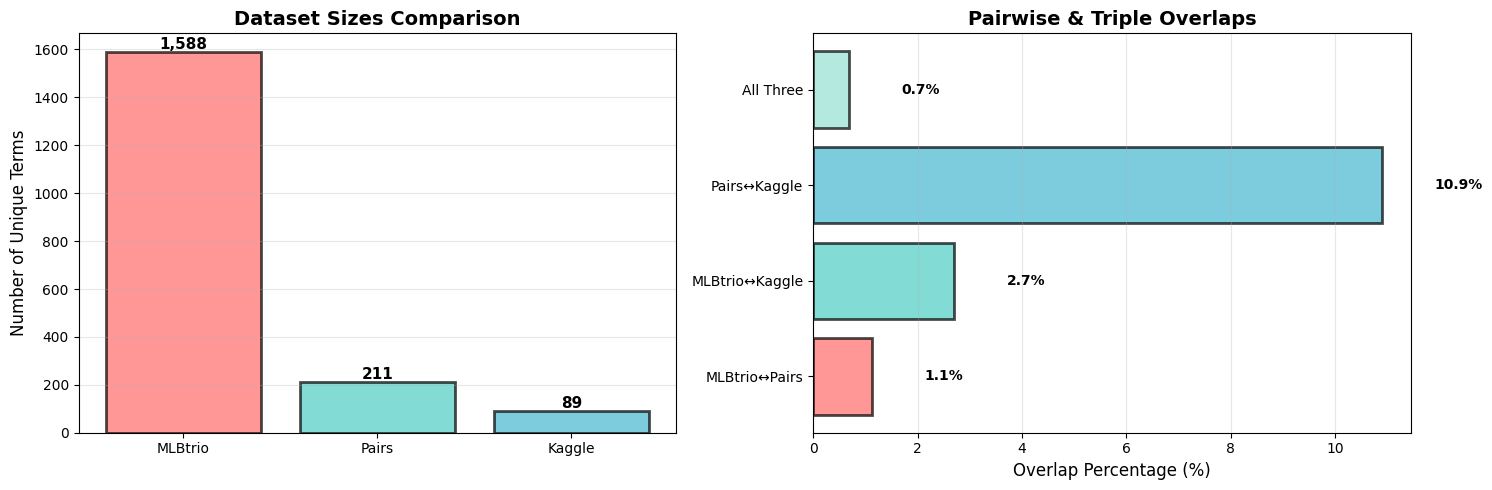

In [ ]:
# --- Create sets of slang terms (normalized) ---
slang_mlbtrio = set(df_mlbtrio.Slang.str.lower())
slang_pair = set(chain.from_iterable(slang_lists))
slang_kaggle  = set(df_kaggle.Slang.str.lower())
print(f"Total unique slang terms in slang_kaggle: {len(slang_kaggle)}")
# --- Compute pairwise intersections and differences ---

# Pair 1: MLBtrio vs Pairs
intersection_1_2 = slang_mlbtrio.intersection(slang_pair)
only_in_mlbtrio = slang_mlbtrio - slang_pair
only_in_pairs = slang_pair - slang_mlbtrio

# Pair 2: MLBtrio vs Kaggle
intersection_1_3 = slang_mlbtrio.intersection(slang_kaggle)
only_in_kaggle_vs_mlbtrio = slang_kaggle - slang_mlbtrio

# Pair 3: Pairs vs Kaggle
intersection_2_3 = slang_pair.intersection(slang_kaggle)
only_in_kaggle_vs_pairs = slang_kaggle - slang_pair

# Triple intersection (all three)
intersection_all = slang_mlbtrio.intersection(slang_pair).intersection(slang_kaggle)

# --- Print comprehensive summary ---
print("=" * 70)
print("SLANG DICTIONARY COMPARISON - THREE DATASETS")
print("=" * 70)

print(f"\nDataset Sizes:")
print(f"  MLBtrio/genz-slang-dataset: {len(slang_mlbtrio):,} unique terms")
print(f"  Programmer-RD-AI/genz-slang-pairs-1k: {len(slang_pair):,} unique terms")
print(f"  Gen Z Words and Phrases Dataset: {len(slang_kaggle):,} unique terms")

print(f"\nPairwise Overlaps:")
print(f"  MLBtrio vs Pairs: {len(intersection_1_2)} shared ({len(intersection_1_2) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  MLBtrio vs Kaggle: {len(intersection_1_3)} shared ({len(intersection_1_3) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  Pairs vs Kaggle: {len(intersection_2_3)} shared ({len(intersection_2_3)/len(slang_pair)*100:.2f}% of Pairs)")

print(f"\nTriple Intersection (in all three): {len(intersection_all)} terms")

print(f"\nUnique Terms (only in one dataset):")
print(f"  Only in MLBtrio: {len(only_in_mlbtrio):,}")
print(f"  Only in Pairs: {len(only_in_pairs):,}")
print(f"  Only in Kaggle: {len(only_in_kaggle_vs_pairs):,}")

# --- Visualizations ---

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Dataset sizes
ax1 = axes[0]
dataset_names = ['MLBtrio', 'Pairs', 'Kaggle']
dataset_sizes = [len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax1.bar(dataset_names, dataset_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Unique Terms', fontsize=12)
ax1.set_title('Dataset Sizes Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, size in zip(bars, dataset_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(size):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Overlap percentages
ax2 = axes[1]
overlap_labels = ['MLBtrio↔Pairs', 'MLBtrio↔Kaggle', 'Pairs↔Kaggle', 'All Three']
overlap_percentages = [
    len(intersection_1_2) / max(len(slang_mlbtrio), len(slang_pair)) * 100,
    len(intersection_1_3) / max(len(slang_mlbtrio), len(slang_kaggle)) * 100,
    len(intersection_2_3) / max(len(slang_pair), len(slang_kaggle)) * 100,
    len(intersection_all) / max(len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)) * 100
]

ax2.barh(overlap_labels, overlap_percentages,
         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'],
         alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xlabel('Overlap Percentage (%)', fontsize=12)
ax2.set_title('Pairwise & Triple Overlaps', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(overlap_percentages):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('three_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

With only 18 shared slang terms (1.1% overlap), merging datasets justifies 1,888 unique terms total. However, structural alignment is required first: all must have `Slang`, `Description`, `Example`, and `Context` columns. The Programmer-RD-AI dataset provides `normal`/`genz` example pairs; we used an LLM to extract `Slang` terms from `genz` text. Some terms appear across multiple examples, and single examples may contain multiple comma-separated terms.

## MLBtrio Alignment
This section adds an `InformalTextWithoutSlang` column to MLBtrio, matching the Pairs dataset structure.

### Iteration 1: Neutral Text Generation

LLM rewrites slang-containing `Example` text into neutral English while preserving original sentiment and intent.

In [ ]:
prompt_formal = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use formal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_formal,
    output_column="Formal_Text"
)
df_mlbtrio.Formal_Text

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv(basepath + genz_slang, index=False)

### Iteration 2: Reduce Formality

Initial LLM outputs were overly formal ("writing English"), unlike Pairs style. A revised prompt generates informal neutral text matching Pairs slang tone.

In [ ]:
prompt_informal_with_slang = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_informal_with_slang,
    output_column="Informal_Text"
)
df_mlbtrio.Informal_Text

See the new column created in the dataset

In [ ]:
df_mlbtrio.head(5)

Save the dataset to a file

In [ ]:
df_mlbtrio.to_csv(genz_slang, index=False)

### Iteration 3: Remove Residual Slang

Final outputs still contained residual slang words. A final prompt explicitly instructs complete slang removal.

In [ ]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio.head(5),
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_mlbtrio.Informal_Text_Without_Slang

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv(genz_slang, index=False)

The generated `InformalTextWithoutSlang` column now produces clean, informal neutral text without slang, successfully aligned with Pairs dataset structure.

## Kaggle Gen Z words Aligment

Standardizes Kaggle dataset to MLBtrio structure: `Slang|Description|Example|Context|InformalTextWithoutSlang`.
LLM rewrites slang-containing `Example` text into neutral English while preserving original sentiment and intent.

In [83]:
df_kaggle = pd.read_csv(basepath + gen_zz_words)

In [22]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_kaggle = client.batch_process(
    df_kaggle,
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_kaggle.Informal_Text_Without_Slang

Processing to Informal_Text_Without_Slang: 100%|██████████| 204/204 [00:53<00:00,  3.79it/s]


0               That brand new tune is a real hum-ditty!
1           I'm skedaddling, catch you on the flip side.
2      She was heavily criticized and shunned followi...
3                              I'm taking it easy today.
4                                   That video was awks.
                             ...                        
199                               Why are you so bitter?
200                            Nailed that presentation!
201                        Was that a subtle jab at all?
202              Keep your eyes open to what's going on.
203                    She has such a voluptuous figure.
Name: Informal_Text_Without_Slang, Length: 204, dtype: object

In [84]:
df_kaggle = df_kaggle[['Slang', 'Description', 'Example', 'Informal_Text_Without_Slang', 'Popularity']]

In [85]:
df_kaggle.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang,Popularity
0,Bop,A song that's really good.,That new track is a bop.,That fresh tune is a real humdinger.,Medium
1,Bounce,To leave or exit.,"I'm bouncing, see you later.","I've got to split, catch you soon.",Medium
2,Cancelled,Publicly denounced and rejected.,She got cancelled after that post.,She was publicly denounced following that post.,High
3,Chill,Relaxed or easy-going.,I'm just chilling today.,I'm taking it easy today.,High
4,Cringe,Embarrassing or awkward.,That video was cringe.,That video was mortifyingly awkward.,High


In [65]:
df_kaggle.to_csv(gen_zz_words, index=False)

### Context field addition
This code generates a new Context column for the Kaggle dataset by using a LLM with a specialized prompt. The prompt instructs the LLM, framed as a conversational analysis expert, to produce concise 2-3 sentence descriptions of the social usage context of each slang term. It focuses on when, where, and who typically uses the term, emphasizing social settings, sentiment, and demographics without naming the slang word itself or including meta-commentary.

In [86]:
prompt_context = """You are a conversational analysis expert specializing in concise context descriptions. Output exactly 2-3 sentences. Maximum 40 words.

Slang: {Slang}
Meaning: {Description}
Example: {Example}

Output 2-3 sentences describing WHEN, WHERE, and WHO uses this term. Format: [social context and usage]
Requirements:
- NO QUOTES, NO BRACKETS, NO META-COMMENTARYs
- Do NOT write the slang term itself in the context
- Describe the usage, not the slang word
- Focus on: social setting (who, when, where), sentiment/tone, demographics

Good examples:
Typically used in conversations to celebrate success, achievements, or positive outcomes
Originally used in activist circles, it has since been co-opted and sometimes used sarcastically.
Often used in informal speech to indicate imminent action, popular in certain dialects of English.


Example text: {Example}

Context:"""

df_kaggle = client.batch_process(
    df_kaggle,
    prompt_template=prompt_context,
    output_column="Context"
)
df_kaggle.Context

Processing to Context: 100%|██████████| 204/204 [03:10<00:00,  1.07it/s]


0      Typically used among friends or on social medi...
1      Often employed casually among friends or peers...
2      Primarily employed in digital discussions, oft...
3      Casual setting among friends or peers, often u...
4      Typically used by younger generations in casua...
                             ...                        
199    Typically utilized in casual conversations amo...
200    Typically employed in casual conversations amo...
201    In casual conversations among teenagers and yo...
202    Often employed in contemporary discussions foc...
203    Often utilized among peers in casual social se...
Name: Context, Length: 204, dtype: object

In [88]:
df_kaggle = df_kaggle[['Slang', 'Description', 'Example', 'Context', 'Informal_Text_Without_Slang', 'Popularity']]

In [89]:
df_kaggle.head(5)

,Slang,Description,Example,Context,Informal_Text_Without_Slang,Popularity
0,Bop,A song that's really good.,That new track is a bop.,Typically used among friends or on social medi...,That fresh tune is a real humdinger.,Medium
1,Bounce,To leave or exit.,"I'm bouncing, see you later.",Often employed casually among friends or peers...,"I've got to split, catch you soon.",Medium
2,Cancelled,Publicly denounced and rejected.,She got cancelled after that post.,"Primarily employed in digital discussions, oft...",She was publicly denounced following that post.,High
3,Chill,Relaxed or easy-going.,I'm just chilling today.,"Casual setting among friends or peers, often u...",I'm taking it easy today.,High
4,Cringe,Embarrassing or awkward.,That video was cringe.,Typically used by younger generations in casua...,That video was mortifyingly awkward.,High


In [91]:
df_kaggle.to_csv(basepath + gen_zz_words, index=False)

## Pairs Aligment 

This section completes Pairs dataset alignment to MLBtrio structure by generating missing `Description` and `Context` fields, plus normalizing multi-slang entries.

In [4]:
df_pairs = pd.read_csv(basepath + genz_slang_pairs)

Some rows contain multiple slang terms in the `Slang` column (e.g., `"Chillin',vibing"`). To match MLBtrio's one-term-per-row format and support term-level embeddings, we expand each row into one row per slang term while keeping the same `Example` and `InformalTextWithoutSlang`.

In [5]:
df_pairs.Slang[5]

'tired, chill'

Split of Multi-Slang Entries into multiple entries

In [6]:
def split_multi_slang(df):
    """
    Convert multi-slang entries into separate rows
    E.g., "vibing, no cap" becomes two rows with same Example
    """
    rows = []
    for idx, row in df.iterrows():
        slang_terms = [s.strip() for s in row['Slang'].split(',')]

        for slang in slang_terms:
            new_row = row.copy()
            new_row['Slang'] = slang  # Single term
            new_row['Original_Slang_List'] = ','.join(slang_terms)  # Keep reference
            rows.append(new_row)

    return pd.DataFrame(rows)

# Apply transformation
df_split = split_multi_slang(df_pairs)

print(f"Before: {len(df_pairs)} rows, {df_pairs['Slang'].nunique()} unique terms")
print(f"After: {len(df_split)} rows, {df_split['Slang'].nunique()} unique terms")

Before: 1005 rows, 378 unique terms
After: 1372 rows, 242 unique terms


First we try to group Slang by each group, but the problem is that we don't see the multiple entries grouped with the since words slangs. strategies handle duplicate slang terms post-expansion (same slang → different examples).

For each slang term with multiple examples, this selects the shortest `Example` by character length using `idxmin()`. So we can look into how each of the examples for the same word is produces and sp

In [ ]:
df_pairs = df_split.loc[df_pairs.groupby('Slang')['Example'].apply(lambda x: x.str.len().idxmin())]
df_pairs

,Slang,Example,Informal_Text_Without_Slang,Original_Slang_List
45,"""hella""",I'm hella drained today.,I'm feeling really tired today.,"""hella"""
83,"""mad""",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,"""mad"""
897,Chillin',"Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Chillin'
943,Chillin',"Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","Chillin',vibing"
943,vibing,"Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","Chillin',vibing"
...,...,...,...,...
892,yeet,"Yo, wanna yeet for some chow later? 🔥","Hey, do you want to go grab some food later?",yeet
459,yo,"Yo, did you catch the new ep of that show yest...","Hey, did you see the new episode of that show ...",yo
484,z's,"Lowkey exhausted today, I gotta catch some Z's.","I'm just really tired today, I think I need so...",z's
64,z's (Z's stands for sleep),"I'm super drained today, I gotta catch some z's.","I'm really tired today, I think I need a nap.",z's (Z's stands for sleep)


Shorter examples produce cleaner sentence transformer embeddings with less noise, better capture core slang usage than verbose contexts, and ensure single row per slang (378 total) for downstream similarity computation.


### Generate Description Field
MLBtrio provides human-written `Description` for each slang term. For Pairs, we generate these automatically using an LLM prompt that sees the slang term and its example usage, producing a concise 1-line definition.


In [ ]:
genz_pairs_v1 = "genz-slang-pairs-1k-v1.csv"

In [ ]:
df_pairs = pd.read_csv(basepath + genz_pairs_v1)

In [ ]:
# Prompt for generating Description field
prompt_context = prompt_context = """You are a linguistics expert specializing in concise definitions. Output exactly 1 line. Maximum 10 words.

Slang: {Slang}
Example: {Example}

Output ONE line only. Format: [short definition]
No brackets, no labels, no explanation, no example, no context, not allowed to used the Slang to describe itself.

Bad: The term "hella" is an informal contraction of "hell of," originating from California's Bay Area in the United States. It is used as an intensifier to emphasize a strong feeling, emotion, or degree. In the sentence "I'm hella drained today," the speaker is expressing extreme feelings of exhaustion or tiredness.
Good: being politically aware
Good: The greatest of all time
Good: Fam is a shorter word for family, but don't be fooled– it can be used to describe your friends or the way Millennials use "bro".

Definition:"""

df_pairs = client.batch_process(
    df_pairs,
    prompt_template=prompt_context,
    output_column="Description"
)
df_pairs.Description

Processing to Description: 100%|██████████| 650/650 [03:41<00:00,  2.93it/s]


0                  Intensifier meaning extremely or very
1                 Angry or frustrated, often informally.
2         Casually relaxing, informally enjoying leisure
3      Casual relaxation, typically with social inter...
4      Enjoying oneself in a relaxed, positive manner...
                             ...                        
645    Casual exclamation indicating enthusiasm or ap...
646    Informal greeting, often used in casual conver...
647    Sleep (noun): informal abbreviation for "sleep...
648    A common slang term referring to sleep. Exampl...
649              intensified exasperation or frustration
Name: Description, Length: 650, dtype: object

In [ ]:
df_pairs.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."


In [ ]:
df_pairs = df_pairs[['Slang', 'Description', 'Example', 'Informal_Text_Without_Slang']]
df_pairs.head(5)


,Slang,Description,Example,Informal_Text_Without_Slang
45,"""hella""","The term ""hella"" is an informal contraction of...",I'm hella drained today.,I'm feeling really tired today.
83,"""mad""","The slang term ""mad"" as used in the sentence ""...",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...
897,Chillin',"The slang term ""chillin'"" as used in the phras...","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and..."
943,Chillin',"The term ""chillin'"" is a colloquial expression...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."
943,vibing,"The slang term ""vibing,"" as used in the given ...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."


In [ ]:
df_pairs.to_csv(basepath + genz_pairs_v1, index=False)

The Pairs data now contrains a good description for each of the slang terms.

### Generate Description Field
MLBtrio provides human-written `Context` for each slang term. For Pairs, we generate these automatically using an LLM prompt that sees the slang term and its example usage, description, producing a 2-3 sentences of content the word would accour.

In [ ]:
prompt_context = """You are a conversational analysis expert specializing in concise context descriptions. Output exactly 2-3 sentences. Maximum 40 words.

Slang: {Slang}
Meaning: {Description}
Example: {Example}

Output 2-3 sentences describing WHEN, WHERE, and WHO uses this term. Format: [social context and usage]
Requirements:
- NO QUOTES, NO BRACKETS, NO META-COMMENTARYs
- Do NOT write the slang term itself in the context
- Describe the usage, not the slang word
- Focus on: social setting (who, when, where), sentiment/tone, demographics

Good examples:
Typically used in conversations to celebrate success, achievements, or positive outcomes
Originally used in activist circles, it has since been co-opted and sometimes used sarcastically.
Often used in informal speech to indicate imminent action, popular in certain dialects of English.


Example text: {Example}

Context:"""

df_pairs = client.batch_process(
    df_pairs,
    prompt_template=prompt_context,
    output_column="Context"
)
df_pairs.Context

Processing to Context: 100%|██████████| 650/650 [10:20<00:00,  1.05it/s]


0      Typically expressed in casual conversations, p...
1      Typically expressed among peers or casual acqu...
2      Typically utilized among friends or peers duri...
3      In informal settings among friends or peers, o...
4      In casual social settings, often among friends...
                             ...                        
645    In casual, youthful social settings, typically...
646    In casual settings among friends or peers, oft...
647    Commonly used among friends and peers during c...
648    Typically utilized in informal settings among ...
649    Often utilized among young adults or students ...
Name: Context, Length: 650, dtype: object

In [ ]:
df_pairs.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang,Context
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,I'm feeling really tired today.,"Typically expressed in casual conversations, p..."
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,Typically expressed among peers or casual acqu...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Typically utilized among friends or peers duri...
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","In informal settings among friends or peers, o..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","In casual social settings, often among friends..."


In [ ]:
df_pairs = df_pairs[['Slang', 'Description', 'Example', 'Context', 'Informal_Text_Without_Slang']]
df_pairs.head(5)


,Slang,Description,Example,Context,Informal_Text_Without_Slang
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","In informal settings among friends or peers, o...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."


In [ ]:
df_pairs.to_csv(basepath + genz_pairs_v1, index=False)

With `Description` generation for Pairs completed, all three datasets now share identical structure: `Slang`, `Description`, `Example`, `InformalTextWithoutSlang`, `Context`.

## Data assembly
This section merges the three Gen Z slang datasets (MLBtrio, Programmer-RD-AI pairs, and Kaggle Gen Z words) into a unified corpus with standardized columns: `Slang`, `Description`, `Example`, `Context`, and `InformalTextWithoutSlang`.

In [ ]:
df_pairs = pd.read_csv(basepath + genz_pairs_v1)
df_mlbtrio = pd.read_csv(basepath + genz_slang)
df_kaggle = pd.read_csv(basepath + gen_zz_words)

The column `Informal_Text_Without_Slang` was originally named to reduce confusion when generating different text styles. However, since we decided to use this column extensively, it is renamed to a clearer and easier-to-understand name, `Neutral_Text`. After this renaming, we concatenate all three datasets to create a unified data frame for further processing.

In [ ]:
# Select only the columns you need and rename last column
columns_to_keep = ["Slang", "Description", "Example", "Context", "Informal_Text_Without_Slang"]

df_unique_filtered = df_pairs[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})
df_mlbtrio_filtered = df_mlbtrio[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})
df_kaggle_filtered = df_kaggle[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})

# Merge all three datasets
df_merged = pd.concat([df_unique_filtered, df_mlbtrio_filtered, df_kaggle_filtered], ignore_index=True)
print(f"Merged dataset shape: {df_merged.shape}")

Merged dataset shape: (2633, 5)


In [41]:
df_merged.head(5)

,Slang,Description,Example,Context,Neutral_Text
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","In informal settings among friends or peers, o...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."


In [42]:
df_merged.to_csv(basepath + "genz_slang_data.csv", index=False)

Analyze the merged dataset for duplication in the `Slang` column

In [43]:
analysis_merged : Dict = analyser.analyze(
    df_merged,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_merged)
analyser.show_duplication_analysis(analysis_merged)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"2,633"
1,Unique (Case-Sensitive),"1,901"
2,Unique (Lowercase),"1,844"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),30.0%
1,Most Common Term,'drained'
2,Most Common Count,48
3,Original Cases,['drained']



The analysis reveals a **30% duplication rate**. A case-sensitive deduplication step is applied using `drop_duplicates(subset=["Slang"])` to preserve distinct entries with different capitalizations, descriptions, or meanings across source datasets.

In [46]:
df_merged_nodup = df_merged.drop_duplicates(subset=["Slang"])

analysis_merged : Dict = analyser.analyze(
    df_merged_nodup,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_merged)
analyser.show_duplication_analysis(analysis_merged)

df_merged_nodup.to_csv(basepath + "genz_slang_data.csv", index=False)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,901"
1,Unique (Case-Sensitive),"1,901"
2,Unique (Lowercase),"1,844"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),3.0%
1,Most Common Term,'fam'
2,Most Common Count,3
3,Original Cases,"['fam', 'Fam', 'FAM']"


From this point forward, the pipeline uses two primary datasets: the merged Gen Z slang corpus (`genz_slang_data.csv`) and the TL;DR summarization corpus. `genz_slang_data.csv` consist of 1,901 slang terms, where no missing values, case-sensitive deduplication.

## TL;DR data analysis

### Exploratory Data Analysis

Load the TL;DR summarization dataset from Hugging Face, examine split distribution, and inspect sample structure

In [4]:

print("Loading TL;DR dataset from Hugging Face...")
dataset = load_dataset("trl-lib/tldr", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)

train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

print(f"Dataset sizes: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

total = len(train_ds) + len(val_ds) + len(test_ds)
print(f"Dataset split percentages: Train={len(train_ds)/total*100:.2f}%, Val={len(val_ds)/total*100:.2f}%, Test={len(test_ds)/total*100:.2f}%")
pd.DataFrame(train_ds).head(5)

Loading TL;DR dataset from Hugging Face...


Generating train split:   0%|          | 0/116722 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6447 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6553 [00:00<?, ? examples/s]

Dataset sizes: Train=116722, Val=6447, Test=6553
Dataset split percentages: Train=89.98%, Val=4.97%, Test=5.05%


,prompt,completion
0,SUBREDDIT: r/relationships\n\nTITLE: I (f/22) ...,I still have contact with an old ex's friends...
1,SUBREDDIT: r/loseit\n\nTITLE: SV & NSV! Keepin...,"Progress is still happening, even when you th..."
2,SUBREDDIT: r/relationships\n\nTITLE: Me [19F] ...,My skin is scarred badly; what could I do/say...
3,SUBREDDIT: r/personalfinance\n\nTITLE: Priorit...,$14k in student debt (all <5%) and need to sa...
4,SUBREDDIT: r/relationships\n\nTITLE: My[25m] g...,"GF is a meanie-bo-beanie when I'm nice, and a..."


As we can observe, the split for the TL;DR dataset has percentages: Train=89.98%, Val=4.97%, Test=5.05%. It consist of a prompt and a completion. We clean the prompt and completion fields by removing newlines and extra whitespace to standardize text formatting across the dataset.

In [5]:

train_ds = train_ds.map(normalize_text, desc="Normalizing train")
val_ds = val_ds.map(normalize_text, desc="Normalizing validation")
test_ds = test_ds.map(normalize_text, desc="Normalizing test")

Normalizing train:   0%|          | 0/116722 [00:00<?, ? examples/s]

Normalizing validation:   0%|          | 0/6447 [00:00<?, ? examples/s]

Normalizing test:   0%|          | 0/6553 [00:00<?, ? examples/s]

#### Merge Dataset Splits for Analysis
Combine train/validation/test splits into a single DataFrame for unified analysis:

In [4]:
df_tldr = pd.concat([train_ds.to_pandas(), test_ds.to_pandas(), val_ds.to_pandas()], ignore_index=True)
print(f"\nCombined dataset shape: {df_tldr.shape}")


Combined dataset shape: (129722, 2)


Verify all TL;DR entries contain English text to enable English-specific tokenizers and preprocessing

In [5]:
langauge = sample_lang_distribution(df_tldr)
print(langauge)

en    1.0
Name: proportion, dtype: float64


Confirm no missing values in core columns to ensure data integrity

In [6]:
missing_counts = df_tldr.isnull().sum()
missing_percent = (df_tldr.isnull().sum() / len(df_tldr)) * 100

print("\nMissing values by column for the whole TL;DR dataset:")
for col, count in missing_counts.items():
    pct = missing_percent[col]
    print(f"  {col}: {count} ({pct:.4f}%)")


Missing values by column for the whole TL;DR dataset:
  prompt: 0 (0.0000%)
  completion: 0 (0.0000%)


Calculate word counts and compression ratios to characterize TL;DR summarization patterns

In [5]:
tldr_stats, stats_summary = compute_tldr_stats(df_tldr)
display(tldr_stats, include_index=False)
display(stats_summary, include_index=False)

,prompt_word_length,completion_word_length,compression_ratio
0,356,40,8.900000
1,215,28,7.678571
2,213,27,7.888889
3,190,25,7.600000
4,278,26,10.692307
...,...,...,...
129717,210,26,8.076923
129718,347,34,10.205882
129719,409,22,18.590908
129720,333,32,10.406250


,Metric,Prompt Length,Completion Length,Compression Ratio
0,Mean,266.425417,27.030419,10.244642
1,Variance,6027.481201,34.679258,12.742166
2,Std Dev,77.636855,5.888910,3.569617
3,Coefficient of Variation,0.291402,0.217862,0.348437
4,Max,442.000000,47.000000,52.428564
5,Min,11.000000,7.000000,0.343750


Two-part visualization: overlaid histograms with mean and ±1σ bands showing distribution patterns, followed by box plots comparing quartile ranges between prompts and completions to highlight compression and statistical spread.

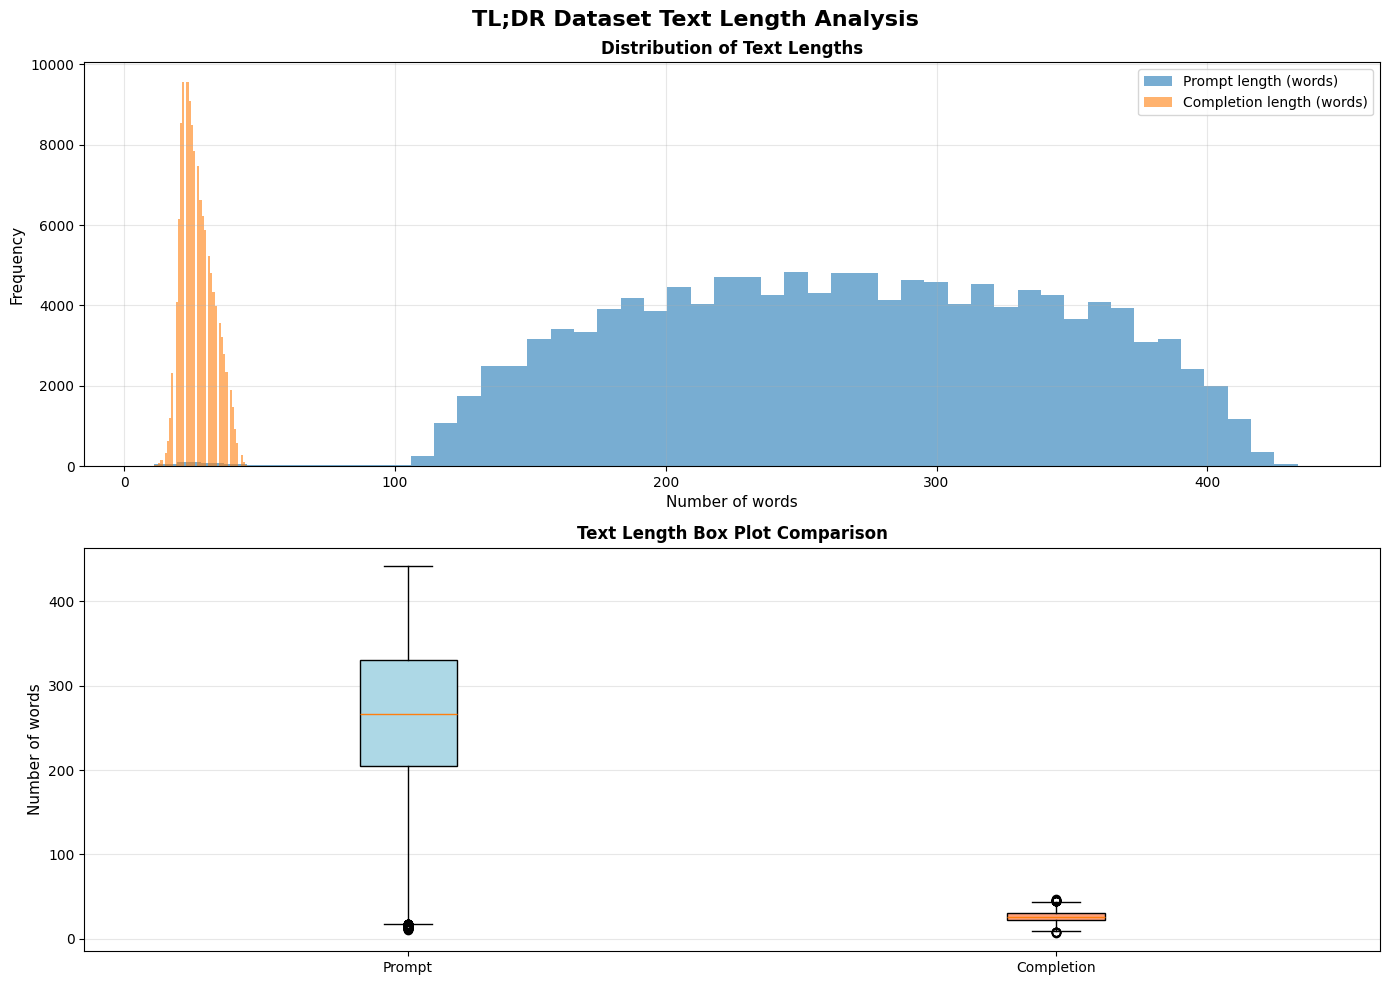

In [6]:
from scripts.libs.tldr_plots import plot_tldr_analysis
plot_tldr_analysis(tldr_stats)

Calculate the intersection-over-union (unigram-level) between prompts and completions to measure semantic overlap and textual alignment.

In [9]:
import numpy as np
from scripts.libs.tldr_stats import compute_alignment_stats

tldr_alignment_stats = compute_alignment_stats(df_tldr)

tldr_alignment_stats['iou_mean'] = float(np.mean(tldr_alignment_stats['iou']))
tldr_alignment_stats['iou_p95'] = float(np.percentile(tldr_alignment_stats['iou'], 95))
tldr_alignment_stats['len_ratio_mean_chars'] = float(np.mean(tldr_alignment_stats['len_ratio']))
tldr_alignment_stats['len_ratio_p95_chars'] = float(np.percentile(tldr_alignment_stats['len_ratio'], 95))

display(tldr_alignment_stats.describe())

,iou,len_ratio,iou_mean,iou_p95,len_ratio_mean_chars,len_ratio_p95_chars
count,129722.000000,129722.000000,129722.000000,129722.000000,1.297220e+05,129722.000000
mean,0.096537,0.111022,0.096537,0.158879,1.110219e-01,0.188453
std,0.034110,0.059652,0.000000,0.000000,2.775568e-17,0.000000
min,0.000000,0.035389,0.096537,0.158879,1.110219e-01,0.188453
25%,0.072626,0.079658,0.096537,0.158879,1.110219e-01,0.188453
50%,0.091954,0.100735,0.096537,0.158879,1.110219e-01,0.188453
75%,0.115385,0.129909,0.096537,0.158879,1.110219e-01,0.188453
max,0.514286,2.423077,0.096537,0.158879,1.110219e-01,0.188453


onvert prompt and completion fields to token IDs using the T5-small tokenizer, capturing token lengths for both fields and their sum. Compute mean and 95th percentile statistics for prompt, completion, and total token lengths to understand model input requirements.

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-small")
from scripts.libs.tldr_stats import tokenize_texts

token_stats, token_summary = tokenize_texts(df_tldr, None, tokenizer)
display(token_stats, index=False)
display(token_summary, index=False)


,prompt_tok_len,completion_tok_len,total_tok_len
0,417,46,463
1,286,36,322
2,278,34,312
3,263,39,302
4,350,41,391
...,...,...,...
129717,271,35,306
129718,442,41,483
129719,462,24,486
129720,402,37,439


,Metric,Value
0,prompt_tok_mean,329.40
1,prompt_tok_p95,472.00
2,completion_tok_mean,32.44
3,completion_tok_p95,45.00
4,total_tok_p95,506.00


Implement and evaluate a simple baseline model that echoes the first 32 tokens of each prompt. Measure prediction quality using ROUGE and chrF metrics against the ground-truth completions.

In [13]:
metrics = evaluate_echo_baseline(test_ds, tokenizer)
display(metrics)

,Metric,Value
0,ROUGE-1,0.2250
1,ROUGE-2,0.0755
2,ROUGE-L,0.1761
3,chrF,19.3121


The TL;DR dataset was explored to understand its structure and content. The dataset consists of 129,722 examples, each containing a Reddit post (`prompt`) and its corresponding TL;DR summary (`completion`). No missing values were found in either column.

Text length analysis showed that posts contain an average of about 266 words, while summaries average around 27 words, indicating a high level of compression (roughly a 10:1 ratio). This characteristic length can be illustrated by generating a histogram of the text lengths, which shows that the spread (standard deviation) of the completion is seven times smaller than the prompt. Therefore, TL;DR summaries have very consistent lengths that we aim to maintain in our model's output.

To assess the quality of the TL;DR dataset, we performed a thorough analysis evaluating data cleanliness, diversity, alignment between prompts and summaries, token length distributions, potential privacy concerns, and establishing a summarization performance baseline.

These analyses show that the dataset appears to be high-quality and predominantly English, as evidenced by the language fraction of 1.0 for the training set. Prompt-completion alignment metrics show low lexical overlap (mean Jaccard ~0.097).

Tokenization statistics reveal that 95% of prompts fit within 472 tokens and completions within 45 tokens, with the combined 95th percentile at 506 tokens—guiding a reasonable maximum sequence length for model training.

Finally, the echo baseline, which simply outputs truncated prompts, performs poorly (ROUGE-1 ≈ 0.22, ROUGE-2 ≈ 0.07, ROUGE-L ≈ 0.17, chrF ≈ 19.31), confirming that the dataset presents a non-trivial summarization task and leaves substantial room for model improvement. Overall, these metrics indicate a clean, English-focused summarization dataset and a realistic challenge for training models.


## Gen Z Slang Dataset Generation For TL;DR

This section shows how the notebook creates Gen Z-style summaries for the TL;DR dataset. It finds matching slang by comparing sentence embeddings, then uses the best matches for LLM prompting. Each original TL;DR summary gets rewritten to keep the same meaning but sound like Gen Z speech.

### Embedding NeutralText with Sentence Transformers

To match TL;DR summaries with relevant slang, the notebook embeds the `NeutralText` column using the sentence transformer `all-MiniLM-L6-v2`. Each neutral paraphrase maps to a fixed-size vector, creating an embedding matrix where:

- Each **row** corresponds to one slang term.
- Semantically similar TL;DR completions cluster near relevant neutral paraphrases in vector space.
- These slang embeddings are **reused** across all TL;DR examples.

In [ ]:
genz_slang_data = "genz_slang_data.csv"
tldr_data = "tldr.csv"

In [ ]:
df_genz = pd.read_csv(basepath + genz_slang_data)
df_genz.head(5)

,Slang,Description,Example,Context,Neutral_Text
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."
4,OOTD,Outfit of the day,"OOTD, just vibing with the crew today, no cap.",Typically exchanged among young adults on soci...,I'm just planning to hang out with friends thi...


First step is to calculates semantic similarity between each TL;DR completion and all 1,901 slang terms. This uses the SentenceTransformer `all-MiniLM-L6-v2` to convert every `NeutralText` entry into a dense vector embedding.

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
slang_embeddings = model.encode(df_genz['Neutral_Text'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 60/60 [00:04<00:00, 13.11it/s]


For every TL;DR `completion` (116,722 training examples), the notebook computes cosine similarity against the pre-computed slang embeddings. Each TL;DR post gets a similarity score (0.0-1.0) for all 1,901 slang terms, forming a ranked list of best matches.

In [ ]:
# Step 1: Compute all similarities
df_train = train_ds.to_pandas()

df_with_sims = compute_all_similarities(
    df=df_train,
    genz_data=df_genz,
    model=model,
    slang_embeddings=slang_embeddings
)

df_with_sims.to_csv(basepath + tldr_data)
display(df_with_sims.head(5))


Computing similarities for each TL;DR...


Computing similarities: 100%|██████████| 116722/116722 [28:12<00:00, 68.95it/s] 


We then analyze the similarity distribution across all 1,901 slang embeddings for one TL;DR completion.

Similarity stats - Count: 1901, Mean: 0.3355, Std: 0.1133, Min: 0.0000, Max: 1.0000


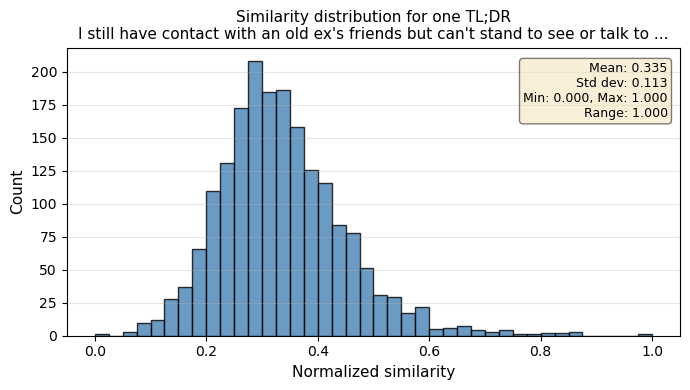

In [ ]:
# Analyze first post's distribution
df_with_sims = pd.read_csv(basepath + tldr_data)
stats_dict = analyze_similarity_distribution_simple(df_with_sims, row_idx=0)

For the first post, the similarity distribution across all 1,901 slang embeddings shows: mean = 0.3355, std = 0.1133, min = 0.0000, max = 1.0000. This reveals most slang terms have moderate similarity to the TL;DR completion, while a few are nearly unrelated (≈0) or semantically identical (≈1).


The raw statistics make it hard to identify which slang terms best match each TL;DR completion. To make this interpretable, we extract the top 20 highest-scoring slang terms and examine their similarity scores alongside the actual `NeutralText` content.

In [ ]:
k=20

row = df_with_sims.iloc[0]
similarities = np.array([float(x) for x in row['all_similarities'].split(';')])

top_k_indices = get_top_k_indices(  
    similarities=similarities,
    k=k
)

display(f"Completion: {df_with_sims.iloc[0]['completion']}\n")

result_df = pd.DataFrame([
    {
        'Similarity': f"{similarities[idx]:.4f}",
        'Slang': df_genz.iloc[idx]['Slang'],
        'Description': df_genz.iloc[idx]['Description']
    }
    for idx in top_k_indices
])
display(result_df)


"Completion: I still have contact with an old ex's friends but can't stand to see or talk to him. His friends are really nice ,so how do I tell them I possibly want to unfriend them on Facebook because of him?\n"

,Similarity,Slang,Description
0,1.0000,FBFR,FaceBook friend
1,0.8618,Zombie-ing,"This happens after someone ghosts you, and the..."
2,0.8617,BFFN,Best friend for now
3,0.8547,Thirsty,"Stands for desperate, usually for attention"
4,0.8336,AAYF,"As always, your friend"
5,0.8304,FWB,Friend with benefits
6,0.8147,FBO,Facebook official
7,0.8098,BFFL,Best friends for life
8,0.7872,MU,Miss you
9,0.7632,FB,Facebook


The top-20 most similar slang terms include relationship- and social-media-related items: **FBFR** (1.0000, highest), Zombie-ing, BFFN, FBO, FWB, plus generic terms like no cap, OOTD, and flex. Many explicitly reference Facebook or close-friend relationships, confirming the embedding model correctly captures the TL;DR post's social/relationship theme.


TL;DR completions are short, so >8 slang terms overwhelm the LLM prompt. Topk=8 keeps high-confidence matches  only.

**Why k=8 works**: Pure theme focus (Facebook/breakup slang).

**Risk**: Misses good-but-not-perfect slang (e.g., "FB" at 0.76), limiting Gen Z style variety.

In [ ]:
tldr_with_top_k = "tldr_top_k.csv"
df_tldr_with_top_k = apply_top_k_selection(df_with_sims, max_k=8)

df_tldr_with_top_k.to_csv(basepath + tldr_with_top_k)
print(f"Saved: {tldr_with_top_k}")


Selecting top-8 slang words...


Selecting top-k slang: 100%|██████████| 116722/116722 [02:35<00:00, 752.98it/s]


✓ Selected top-8 slang words
  Added columns: ['top_k_slang', 'top_k_slang_count']

Saved: tldr_top_k.csv


In [ ]:
display(df_tldr_with_top_k.head(5))

,Unnamed: 0,prompt,completion,all_slang,all_similarities,top_k_slang,top_k_slang_count
0,0,SUBREDDIT: r/relationships TITLE: I (f/22) hav...,I still have contact with an old ex's friends ...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.324210;0.306928;0.253868;0.272921;0.704904;0...,FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FB...,8
1,1,SUBREDDIT: r/loseit TITLE: SV & NSV! Keeping o...,"Progress is still happening, even when you thi...","""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.498610;0.605956;0.586507;0.468540;0.389142;0...,NSA; WB; DITYID; FISH; AYDY; Hits Different; D...,8
2,2,SUBREDDIT: r/relationships TITLE: Me [19F] wit...,My skin is scarred badly; what could I do/say ...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.325442;0.182998;0.291735;0.212317;0.294495;0...,DIY; IAAD; MYOB; Snatched; Beat your face; OMA...,8
3,3,SUBREDDIT: r/personalfinance TITLE: Prioritize...,$14k in student debt (all <5%) and need to sav...,"""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.326683;0.541999;0.547360;0.404891;0.393326;0...,IAAA; Sheesh; WDYT; DYOR; Gaup; TM; BOHICA; AFAP,8
4,4,SUBREDDIT: r/relationships TITLE: My[25m] girl...,"GF is a meanie-bo-beanie when I'm nice, and an...","""hella"";""mad"";Chillin';vibing;OOTD;no cap;Z's;...",0.480018;0.383189;0.271994;0.498448;0.398034;0...,GF; KOC; G/F; PYT; GRL; HUYA; IWSN; LHSX,8


The new columns `top_k_slang` and `top_k_slang_count` are now created. Initial research considered top-p sampling but settled on fixed top-k=8, tracked by `top_k_slang_count`.


With top-k slang extracted for every post, we now reduce memory by dropping intermediate columns: `all_slang`, `all_similarities`, `top_k_slang_count`, and `Unnamed: 0`.


In [ ]:
# drop the columns not needed anymore
df_tldr_with_top_k.drop(columns=['all_slang', 'all_similarities', 'top_k_slang_count', 'Unnamed: 0'], inplace=True)
df_tldr_with_top_k.to_csv(basepath + tldr_with_top_k, index=False)

Now with top-8 slang matches for each TL;DR post, we can generate Gen Z-style completions.

### Generating Gen Z-Style TL;DR Completions

We use a cloud LLM (Gradient + Llama3-8b-instruct) for batch inference across posts. Llama3-8b is chosen for cost-efficiency while handling the scale with proper prompt configuration.


In [35]:
tldr_with_top_k = "tldr_top_k.csv"
checkpoint_file = "tldr_with_genz_checkpoint.csv"
final_file = "tldr_with_genz.csv"

df_tldr_with_top_k = pd.read_csv(basepath + tldr_with_top_k)

The code implements batch inference with error handling due to frequent Gradient API failures. **LLM assisted in creating the error handling logic.** Key features: rate limiting (15 req/min), exponential backoff retries (5x), and checkpointing every 30 completions.

**System prompt enforces**:
- ≥2 slang terms from top-8 list
- Natural usage (no "lowFOMOkey")
- Preserve meaning + length (±20%)
- Output only rewritten text

**Error resilience**: OOM/500/timeout errors retry with 2^attempt backoff. Checkpoints save completed rows only.


In [ ]:
# Initialize Gradient client with model access key
inference_client = Gradient(model_access_key=os.getenv("GRADIENT_API_KEY"))

SYSTEM_PROMPT = """You are a Gen Z linguist. Rewrite summaries in authentic Gen Z style using MORE THAN 2 slang terms from the provided list. You only translate the summary, nothing else.

CORE RULES:
1. ALWAYS use 2 OR MORE slang words from the provided list.
2. Slang must be COMPLETE, standalone words (never embedded: "lowFOMOkey" is wrong)
3. Slang must fit naturally—no forced placement
4. Preserve ALL information and meaning 100%
5. Keep length within ±20% of original
6. Output ONLY the rewritten summary—no explanations
7. No emojis, asterisks, or special characters
8. Match original tone (casual, critical, neutral, etc.)
9. Do not provide any commentary on the slang usage
10. Do not answer the sentence. 

EXAMPLES:
good: "Low-key this hits different" (slang visible, natural)
bad: "It's lowFOMOkey" (slang embedded)
bad: "FOMO about the vibe" (forced placement)

GEN Z STYLE: Conversational, casual connectors, can use sarcasm/exaggeration.

RESPOND WITH ONLY THE REWRITTEN TEXT. NOTHING ELSE. NO EXCEPTIONS."""

REQUESTS_PER_MINUTE = 3
MAX_RETRIES = 5
RETRY_BACKOFF = 2  # Exponential backoff multiplier
MAX_ROWS = 30000  #  Set to 30k
CHECKPOINT_INTERVAL = 30


request_times = []

def rate_limit_check():
    """Enforce rate limiting by tracking request times"""
    global request_times
    current_time = time.time()
    request_times = [t for t in request_times if current_time - t < 60]
    
    if len(request_times) >= REQUESTS_PER_MINUTE:
        sleep_time = 60 - (current_time - request_times[0]) + 0.1
        print(f"Rate limit reached. Waiting {sleep_time:.1f}s...")
        time.sleep(sleep_time)
        request_times = []
    
    request_times.append(time.time())

def generate_genz_completion(original_completion, top_k_slang, model="llama3-8b-instruct"):
    """Rewrite original TL;DR into GenZ style with exponential backoff retry"""
    
    for attempt in range(MAX_RETRIES):
        rate_limit_check()
        
        try:
            message = inference_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": f"""Available slang words: {top_k_slang}


Original summary: {original_completion}


Rewrite this in authentic Gen Z style."""
                    }
                ],
                max_tokens=256,
                temperature=0.7,
                top_p=0.9
            )
            return message.choices[0].message.content
            
        except Exception as e:
            error_str = str(e).lower()
            
            if "oom" in error_str or "500" in error_str or "timeout" in error_str or "502" in error_str or "503" in error_str:
                if attempt < MAX_RETRIES - 1:
                    wait_time = (RETRY_BACKOFF ** attempt)
                    print(f"API error (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    print(f"   Retrying in {wait_time}s...")
                    time.sleep(wait_time)
                    continue
                else:
                    print(f"Max retries exceeded. Skipping row.")
                    return None
            else:
                print(f"Error generating completion: {e}")
                return None
    
    return None
    
def save_checkpoint_efficient(df, checkpoint_file, idx):
    """Save only completed rows to reduce memory/disk usage"""
    # Save only rows with GenZ_completion (more efficient)
    completed = df[df['GenZ_completion'].notna()].copy()
    
    if len(completed) > 0:
        completed.to_csv(checkpoint_file, index=False)
        return completed['GenZ_completion'].last_valid_index()
    return None


# Load or initialize checkpoint
checkpoint_file = "tldr_with_genz_checkpoint.csv"
if os.path.exists(checkpoint_file):
    print(f"Loading checkpoint from {checkpoint_file}...")
    checkpoint_df = pd.read_csv(checkpoint_file)
    
    # Copy completed results to progress dataframe
    tldr_df_progress = df_tldr_with_top_k.copy()  # ← Start with full 30k
    tldr_df_progress['GenZ_completion'] = None
    
    for idx in checkpoint_df.index:
        tldr_df_progress.loc[idx, 'GenZ_completion'] = checkpoint_df.loc[idx, 'GenZ_completion']
    
    last_completed_idx = tldr_df_progress['GenZ_completion'].last_valid_index()
    
    if last_completed_idx is not None:
        start_idx = last_completed_idx + 1
        print(f"Last completed: row {last_completed_idx}")
        print(f"Resuming from row {start_idx}...")
    else:
        start_idx = 0
else:
    tldr_df_progress = df_tldr_with_top_k.copy()
    tldr_df_progress['GenZ_completion'] = None
    start_idx = 0
    print(f"Creating new checkpoint file...")


# Generate GenZ completions with rate limiting
print(f"Generating GenZ completions with rate limit: {REQUESTS_PER_MINUTE} req/min...")
print(f"Max rows to process: {MAX_ROWS}")
print(f"Starting at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

batch_count = 0
checkpoint_batch = 0
error_count = 0

end_idx = min(MAX_ROWS, len(tldr_df_progress))

for idx in range(start_idx, MAX_ROWS):
    row = tldr_df_progress.iloc[idx]
    
    genz_completion = generate_genz_completion(
        row['completion'], 
        row['top_k_slang']
    )
    
    if genz_completion:
        tldr_df_progress.loc[idx, 'GenZ_completion'] = genz_completion
        batch_count += 1
        checkpoint_batch += 1
    else:
        error_count += 1
    
    # Save checkpoint every N completions (only completed rows)
    if checkpoint_batch % CHECKPOINT_INTERVAL == 0 and checkpoint_batch > 0:
        last_completed = save_checkpoint_efficient(tldr_df_progress, checkpoint_file, idx)
        print(f"Generated {batch_count} total completions. Last completed row: {last_completed}. Checkpoint saved.")
        checkpoint_batch = 0
    
    # Show progress every 50 rows processed
    if (idx - start_idx + 1) % 50 == 0:
        total_to_process = end_idx - start_idx
        processed = idx - start_idx + 1
        progress_pct = (processed / total_to_process) * 100
        print(f"Progress: {idx + 1} / {end_idx} ({progress_pct:.1f}%) | Errors: {error_count}")
        
        
# Save final results and display samples
final_df = tldr_df_progress[tldr_df_progress['GenZ_completion'].notna()].copy()
final_df.to_csv(final_file, index=False)

total_completed = len(final_df)
print(f"\nGenerated GenZ completions for {total_completed} / {end_idx} TL;DR posts")
print(f"Final results saved to {final_file}")

# Display sample results
print("\n=== Sample Results ===")
for i, (idx, row) in enumerate(final_df.head(3).iterrows()):
    print(f"\n[{i}]")
    print(f"Original: {row['completion'][:100]}...")
    print(f"Slang used: {row['top_k_slang']}")
    print(f"GenZ version: {row['GenZ_completion'][:100]}...")



We now analyze the generated dataset to determine if the Gen Z completions meet quality standards for downstream training.

### Analysis of the generate data

In [43]:
checkpoint = pd.read_csv(checkpoint_file)
print(checkpoint.columns)
print("Reading the first Reddit index: ")
print("   completion: " + checkpoint.completion[0])
print("   GenZ_completion: " + checkpoint.GenZ_completion[0])
print("   top_k_slang: " + checkpoint.top_k_slang[0])

Index(['prompt', 'completion', 'top_k_slang', 'GenZ_completion'], dtype='object')
Reading the first Reddit index: 
   completion: I still have contact with an old ex's friends but can't stand to see or talk to him. His friends are really nice ,so how do I tell them I possibly want to unfriend them on Facebook because of him?
   GenZ_completion: I'm still connected to my ex's squad on FB, but it's a total lowkey nightmare 'cause they're all super nice, but I'm just not here for my ex, you feel? They're always posting pics with him and I'm just over here, zombie-ing on their feeds, trying not to get too thirsty for drama. I'm trying to figure out how to BFFN them on Facebook without being too harsh, 'cause they're actually really cool, but my ex is just a major turnoff.
   top_k_slang: FBFR; Zombie-ing; BFFN; Thirsty; AAYF; FWB; FBO; BFFL


The model used 6 out of 8 provided slang terms including FB, Zombie-ing, and BFFN which exceeds the minimum requirement of 2 terms. Slang integration appears completely natural as in the phrase zombie-ing on their feeds. All core meaning from the original Facebook unfriending dilemma remains preserved. The generated voice sounds authentically Gen Z through phrases like you feel and not here for my ex. Two slang terms Thirsty and AAYF were not used suggesting selective filtering by the LLM.

In [56]:
def count_slang_usage(row):
    """Count how many slang terms were actually used in the GenZ completion."""
    # Skip rows with missing GenZ_completion
    if pd.isna(row['GenZ_completion']):
        return 0, 0, []
    
    slang_terms = [s.strip() for s in row['top_k_slang'].split(";") if s.strip()]
    genz_text = row['GenZ_completion'].lower()
    
    used_slang = []
    for slang in slang_terms:
        if slang.lower() in genz_text:
            used_slang.append(slang)
    
    return len(used_slang), len(slang_terms), used_slang


# Apply to checkpoint - only rows with GenZ_completion
completed_checkpoint = checkpoint[checkpoint['GenZ_completion'].notna()].copy()

completed_checkpoint[['used_slang_count', 'total_slang_count', 'slang_used_list']] = completed_checkpoint.apply(
    lambda row: pd.Series(count_slang_usage(row)), axis=1
)
completed_checkpoint['slang_usage_rate'] = completed_checkpoint['used_slang_count'] / completed_checkpoint['total_slang_count']


In [57]:
# Summary statistics
print("Slang Usage Statistics:")
print(f"Rows analyzed: {len(completed_checkpoint)}")
print(f"Average slang terms used: {completed_checkpoint['used_slang_count'].mean():.2f} / {completed_checkpoint['total_slang_count'].iloc[0]}")
print(f"Average usage rate: {completed_checkpoint['slang_usage_rate'].mean():.2%}")
print(f"Min usage: {completed_checkpoint['used_slang_count'].min()}")
print(f"Max usage: {completed_checkpoint['used_slang_count'].max()}")

# Distribution
print("\n Slang Usage Distribution:")
usage_dist = completed_checkpoint['used_slang_count'].value_counts().sort_index()
for count, freq in usage_dist.items():
    pct = (freq / len(completed_checkpoint)) * 100
    print(f"{count} slang terms used: {freq} times ({pct:.1f}%)")



Slang Usage Statistics:
Rows analyzed: 23000
Average slang terms used: 2.31 / 8
Average usage rate: 28.82%
Min usage: 0
Max usage: 8

 Slang Usage Distribution:
0 slang terms used: 5353 times (23.3%)
1 slang terms used: 3305 times (14.4%)
2 slang terms used: 3979 times (17.3%)
3 slang terms used: 4159 times (18.1%)
4 slang terms used: 3213 times (14.0%)
5 slang terms used: 1863 times (8.1%)
6 slang terms used: 831 times (3.6%)
7 slang terms used: 242 times (1.1%)
8 slang terms used: 55 times (0.2%)


In [ ]:
for target_count in sorted(completed_checkpoint['used_slang_count'].unique())[:3]:
    example = completed_checkpoint[completed_checkpoint['used_slang_count'] == target_count].iloc[0]
    print(f"\n[Used {target_count} slang terms]")
    print(f"Original: {example['completion']}")
    print(f"Slang available: {example['top_k_slang']}")
    print(f"Slang used: {', '.join(example['slang_used_list'])}")
    print(f"GenZ: {example['GenZ_completion']}")

# Save stats to CSV
stats_file = "slang_usage_stats.csv"
completed_checkpoint[['completion', 'top_k_slang', 'GenZ_completion', 'used_slang_count', 'slang_usage_rate', 'slang_used_list']].to_csv(stats_file, index=False)
print(f"\nStats saved to {stats_file}")


=== Examples ===

[Used 0 slang terms]
Original: My GF wants to pay for helping her with her accounting class, but I don't want to get paid since I think that something like this should be expected in a relationship. Both perspectives are provided in the post.
Slang available: IAAA; Pink flags; FWB; DD; Karen; ITAM; Sheesh; Situationship
Slang used: 
GenZ: My GF is low-key trying to get me to take her cash for helping her with her accounting class, but I'm high-key thinking that's a major pink flag, like, in a relationship, you're supposed to have each other's backs, not get paid for it.

[Used 1 slang terms]
Original: Had a big-ass ovarian cyst; scared that I'm irreparably broken; hormonal shitstorm ensues; worried I'm going to alienate my boyfriend with my behavior.
Slang available: MYOB; TCOY; ACDNT; DLTBBB; IAAD; LERK; HAGO; TC
Slang used: LERK
GenZ: I had a huge ovarian cyst, and I was like totally freaking out, thinking I'm irreparably broken, and then this hormonal shitstorm hi

On average, the model only used 2.3 out of 8 slang words per post (29% usage). The biggest issue is 23% of posts used zero slang words even though 8 good options were provided. Another 14% used just 1 word, so 38% completely ignored the "use at least 2 slang words" rule.

Only 5% of posts used 6+ slang words, and just 0.2% used all 8 perfectly. The model keeps ignoring our slang list and makes up common internet words instead.

In one example, "Pink flags" was available but it used "low-key" and "high-key" instead. In another, it awkwardly squeezed "LERK" into a medical post where it didn't fit. The model cares more about sounding smooth than following instructions.



We don't have time to regenerate the 38% failed outputs. This impacts validation since 23% contain zero slang despite our rules. We could remove them entirely, or analyze what alternative slang the LLM invented and accept those words—but train SFT to prefer our curated wordlist since validation data is easier to create for our specific terms.

In [52]:
### Extract and Analyze 5 Zero-Slang Examples

# Filter zero-slang cases
zero_slang_cases = completed_checkpoint[completed_checkpoint['used_slang_count'] == 0].copy()

print(f"=== Analysis: 5 Zero-Slang Failure Cases ===")
print(f"Total zero-slang cases: {len(zero_slang_cases)} ({len(zero_slang_cases)/len(completed_checkpoint)*100:.1f}%)\n")

# Show first 5 examples
for i in range(min(5, len(zero_slang_cases))):
    example = zero_slang_cases.iloc[i]
    
    print(f"Example {i+1}: {example['completion']}...")
    print(f"   Slang available: {example['top_k_slang']}")
    print(f"   GenZ output: {example['GenZ_completion']}...")
    print()

=== Analysis: 5 Zero-Slang Failure Cases ===
Total zero-slang cases: 5353 (23.3%)

Example 1: My GF wants to pay for helping her with her accounting class, but I don't want to get paid since I think that something like this should be expected in a relationship. Both perspectives are provided in the post....
   Slang available: IAAA; Pink flags; FWB; DD; Karen; ITAM; Sheesh; Situationship
   GenZ output: My GF is low-key trying to get me to take her cash for helping her with her accounting class, but I'm high-key thinking that's a major pink flag, like, in a relationship, you're supposed to have each other's backs, not get paid for it....

Example 2: I try not to give fucks, but eventually fucks are given. Can fucks be ungiven? Help....
   Slang available: IWALU; BME; TTLY; Catch these hands; KNIM; RMLB; DTRT; LVM
   GenZ output: Honestly, I'm low-key over it, but I'll give you the tea - I try not to care, but sometimes I do care, and then I'm like, can I take it back? I'm trying not to

In [ ]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    words = text.split()
    return [word for word in words if word not in stop_words and len(word) > 2]

# Count normalized words
all_zero_slang_words = []
for text in zero_slang_cases['GenZ_completion'].dropna().astype(str):
    words = normalize_text(text)
    all_zero_slang_words.extend(words)

word_counts = Counter(all_zero_slang_words)

print("Top 10 most common NON-STOPWORDS in zero-slang outputs:")
print(word_counts.most_common(10))


Top 10 most common NON-STOPWORDS in zero-slang outputs:
[('lowkey', 4835), ('like', 3070), ('trying', 2569), ('honestly', 1693), ('get', 1680), ('shes', 1485), ('feel', 1342), ('hes', 1200), ('even', 1154), ('got', 1068)]


### Analysis: Zero-Slang Problems

In 5,353 cases (23%), the model ignores our slang list completely. It always uses "lowkey" instead (4,835 times) even when "lowkey" was never provided.

Examples across all topics show the same pattern: ignores "Pink flags", "Situationship", "Sheesh" but adds "lowkey" + "you feel?" automatically.

The model prefers familiar phrases over our specific slang list. This wastes 23% of our data.

In [ ]:
# ============================================================================
# ADD TO CONFIGURATION SECTION
# ============================================================================

# File to save raw API responses for debugging
raw_response_log = "tldr_raw_responses.jsonl"  # One JSON per line
parse_failure_log = "tldr_parse_failures.jsonl"  # Failed parse attempts with raw response

# ============================================================================
# UPDATED parse_batch_output with Response Logging
# ============================================================================

def parse_batch_output(response_text: str, expected_rows: int, batch_num: int = -1) -> Dict[int, str]:
    """
    ENHANCED MULTI-FORMAT PARSER with response logging
    Tries multiple formats to extract ROW_ID|content pairs
    
    Args:
        response_text: Raw API response
        expected_rows: How many rows we expected
        batch_num: Batch number for logging
    
    Returns:
        Dict of {row_id: content} pairs
    """
    results = {}
    
    # Safety check
    if not response_text or not isinstance(response_text, str):
        print(f"    ⚠️ Invalid response type: {type(response_text)}")
        _log_parse_failure(batch_num, expected_rows, response_text, "Invalid response type")
        return results
    
    # Debug: print first 300 chars
    print(f"    Response preview: {response_text[:300]}")
    
    # Try each parser in order (most specific → most general)
    
    # ========================================================================
    # PARSER 1: ROW_N|content (with pipe delimiter - PREFERRED)
    # ========================================================================
    results = _parse_row_pipe(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 1 (ROW_N|content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 2: ROW_N: content (with colon delimiter)
    # ========================================================================
    results = _parse_row_colon(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 2 (ROW_N: content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 3: N|content (just number with pipe, no ROW_ prefix)
    # ========================================================================
    results = _parse_number_pipe(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 3 (N|content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 4: ROW_N → content (arrow delimiter)
    # ========================================================================
    results = _parse_row_arrow(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 4 (ROW_N → content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 5: [ROW_N] content (bracket notation)
    # ========================================================================
    results = _parse_row_brackets(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 5 ([ROW_N] content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 6: **ROW_N** content (markdown bold)
    # ========================================================================
    results = _parse_row_markdown(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 6 (**ROW_N** content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 7: N. content (numbered list 1-indexed)
    # ========================================================================
    results = _parse_numbered_list(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 7 (N. content): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 8: Markdown headers (# ROW_N or ## N)
    # ========================================================================
    results = _parse_markdown_headers(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 8 (# ROW_N): {len(results)} rows")
        return results
    
    # ========================================================================
    # PARSER 9: Last resort - split by newlines and try to extract pattern
    # ========================================================================
    results = _parse_fallback(response_text)
    if len(results) > 0:
        print(f"    ✓ Parser 9 (Fallback): {len(results)} rows")
        return results
    
    # ALL PARSERS FAILED - LOG IT
    print(f"    ✗ All parsers failed - no rows extracted")
    _log_parse_failure(batch_num, expected_rows, response_text, "All parsers failed")
    _log_raw_response(batch_num, response_text, expected_rows, success=False)
    
    return {}


# ============================================================================
# NEW: Response Logging Functions
# ============================================================================

def _log_raw_response(batch_num: int, response_text: str, expected_rows: int, success: bool):
    """
    Log raw API response to file for debugging
    
    Format: One JSON per line (JSONL)
    {
        "batch_num": 5,
        "timestamp": "2025-12-10T16:39:00Z",
        "expected_rows": 750,
        "response_length": 5234,
        "success": false,
        "response": "raw response text...",
        "first_200_chars": "preview..."
    }
    """
    try:
        log_entry = {
            "batch_num": batch_num,
            "timestamp": datetime.now().isoformat(),
            "expected_rows": expected_rows,
            "response_length": len(response_text) if response_text else 0,
            "success": success,
            "response": response_text[:5000] if response_text else "",  # First 5000 chars
            "first_200_chars": response_text[:200] if response_text else ""
        }
        
        with open(raw_response_log, 'a') as f:
            f.write(json.dumps(log_entry) + '\n')
    except Exception as e:
        print(f"    ⚠️ Error logging raw response: {str(e)[:50]}")


def _log_parse_failure(batch_num: int, expected_rows: int, response_text: str, reason: str):
    """
    Log parse failure details for manual review
    
    Format: One JSON per line (JSONL)
    {
        "batch_num": 5,
        "timestamp": "2025-12-10T16:39:00Z",
        "expected_rows": 750,
        "reason": "All parsers failed",
        "response_length": 5234,
        "response_preview": "first 500 chars...",
        "response_full": "entire response text..."
    }
    """
    try:
        log_entry = {
            "batch_num": batch_num,
            "timestamp": datetime.now().isoformat(),
            "expected_rows": expected_rows,
            "reason": reason,
            "response_length": len(response_text) if response_text else 0,
            "response_preview": response_text[:500] if response_text else "",
            "response_full": response_text if response_text else ""
        }
        
        with open(parse_failure_log, 'a') as f:
            f.write(json.dumps(log_entry) + '\n')
    except Exception as e:
        print(f"    ⚠️ Error logging parse failure: {str(e)[:50]}")


def _log_row_extraction(batch_num: int, row_ids: list, extracted_count: int, expected_count: int):
    """
    Log which specific rows were extracted from a batch
    Useful for tracking partial failures
    """
    try:
        log_entry = {
            "batch_num": batch_num,
            "timestamp": datetime.now().isoformat(),
            "expected_rows": expected_count,
            "extracted_rows": extracted_count,
            "extracted_ids": sorted(row_ids),
            "missing_ids": [i for i in range(expected_count) if i not in row_ids]
        }
        
        # Append to extraction log (same file as parse failures for simplicity)
        with open(parse_failure_log, 'a') as f:
            f.write(json.dumps(log_entry) + '\n')
    except Exception as e:
        print(f"    ⚠️ Error logging extraction: {str(e)[:50]}")


In [ ]:
import os
import pandas as pd
import time
import json
import ast
from datetime import datetime
from gradient import Gradient
from typing import List, Dict, Tuple
import re

# ============================================================================
# CONFIGURATION
# ============================================================================

basepath = "./Data/"
genz_slang_data = "genz_slang_data.csv"
tldr_with_top_k = "tldr_top_k.csv"
checkpoint_file = "tldr_gradient_batch_checkpoint.json"
final_file = "tldr_with_genz_gradient_batch.csv"
failed_file = "tldr_failed_rows.csv"  # NEW: Track failed rows
failed_log_file = "tldr_failed_log.json"  # NEW: Detailed failure info

# Initialize Gradient client
inference_client = Gradient(model_access_key=os.getenv("GRADIENT_API_KEY"))

# ============================================================================
# BATCH CONFIGURATION (SMART: Only 15 API calls instead of 30,000!)
# ============================================================================

MODEL = "openai-gpt-oss-120b"
BATCH_SIZE = 50  # Rows per batch (fits in token window)
TOTAL_ROWS = 30000
RATE_LIMIT_DELAY = 20  # Seconds between calls (60/3 = 20 sec = 3 calls/minute)
MAX_RETRIES = 2

# Calculated
TOTAL_BATCHES = (TOTAL_ROWS + BATCH_SIZE - 1) // BATCH_SIZE
CALLS_PER_MINUTE = 60 / RATE_LIMIT_DELAY

print(f"Smart Gradient Batch Configuration (RATE LIMITED):")
print(f"  Total rows: {TOTAL_ROWS}")
print(f"  Batch size: {BATCH_SIZE} rows per API call")
print(f"  Total API calls needed: {TOTAL_BATCHES}")
print(f"  Rate limit delay: {RATE_LIMIT_DELAY}s between calls")
print(f"  Rate limit: {CALLS_PER_MINUTE:.1f} calls/minute (2-3 target) ✅")
print(f"  Estimated time: ~{int(TOTAL_BATCHES * (10 + RATE_LIMIT_DELAY) / 60)} minutes")
print(f"  Estimated cost: $1-3")
print(f"\nOutput files:")
print(f"  - {final_file}")
print(f"  - {failed_file}")
print(f"  - {failed_log_file}")

# ============================================================================
# SYSTEM PROMPT (IMPROVED: Preserves scenario & question)
# ============================================================================

SYSTEM_PROMPT = """You are a Gen Z linguist. Rewrite Reddit TL;DRs in authentic Gen Z dialect.

CRITICAL PRESERVATION RULES (NON-NEGOTIABLE):
1. **PRESERVE THE SCENARIO**: Who are the people? What happened? When/where did it occur?
   - Same characters, relationships, and situation as the original
   - If input is about girlfriend drama, output MUST be about girlfriend drama
   - If input is about friend group conflict, output MUST be about that exact conflict
   
2. **PRESERVE THE QUESTION/CONFLICT**: What is OP asking? What are they conflicted about?
   - Keep the core issue unchanged (dating problem → stays dating problem)
   - The "what should I do?" or "am I wrong?" must address the SAME situation
   - DO NOT change the scenario to a different topic

3. **USE SLANG CONTEXTUALLY**: Slang must fit the actual scenario and tone
   - Relationship conflict → use slang about dating/attraction/feelings
   - Friend drama → use slang about friendships/loyalty/drama
   - NOT random slang that doesn't match what's actually happening
   - Example: Don't use "sus" for a trust/loyalty issue in a dating post

4. **MAINTAIN STRUCTURE**: Keep the same sequence and all key details
   - Timeline of events stays the same
   - Key facts and context are preserved
   - Relationships between characters don't change

VALIDATION CHECK:
Before outputting, ask yourself:
- Is this about the SAME situation as the input?
- Does the core question match?
- Are the characters and relationships the same?
- If any answer is "no", STOP and rewrite to match the input.

OUTPUT FORMAT (REQUIRED - STRICT):
For each input row, output exactly:
ROW_<ID>|<gen_z_rewritten_text>

Example:
ROW_0|Low-key my girlfriend is giving toxic energy - she's mean when I'm sweet and sweet when I'm distant. I'm stuck because the chemistry hits different but this dynamic has me conflicted fr. Should I bounce or try to fix it?
ROW_1|Another rewritten summary here

SLANG EXAMPLES (context-appropriate):
✓ CORRECT: "Low-key this hits different" (natural in any scenario)
✓ CORRECT: For relationship issue: "She's giving toxic vibes" or "The sex hits but the energy is sus"
✓ CORRECT: For friend issue: "Nah they're giving real ones energy" or "That's lowkey two-faced"
✗ WRONG: "Zombie-ing his vibes" (makes no sense, forced)
✗ WRONG: Using "sus" for a completely unrelated situation
✗ WRONG: Changing "girlfriend drama" → "friend group drama"

CRITICAL: Output EVERY row. Start with ROW_0. No skipping. One result per line.
Maintain fidelity to the input scenario above all else."""

# ============================================================================
# LOAD DATA
# ============================================================================

print(f"\nLoading data...")
df_genz = pd.read_csv(basepath + genz_slang_data)
df_tldr_with_top_k = pd.read_csv(basepath + tldr_with_top_k)

# Create slang description mapping
slang_description_map = {}
for idx, row in df_genz.iterrows():
    slang_term = str(row['Slang']).strip()
    description = str(row['Description']).strip() if pd.notna(row['Description']) else slang_term
    slang_description_map[slang_term] = description

print(f"Loaded {len(slang_description_map)} slang terms")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def parse_slang_list(slang_str) -> List[str]:
    """Parse slang list from string format"""
    if isinstance(slang_str, list):
        return slang_str
    
    slang_str = str(slang_str).strip()
    
    try:
        parsed = json.loads(slang_str)
        if isinstance(parsed, list):
            return [str(s).strip() for s in parsed]
    except (json.JSONDecodeError, ValueError):
        pass
    
    try:
        parsed = ast.literal_eval(slang_str)
        if isinstance(parsed, list):
            return [str(s).strip() for s in parsed]
    except (ValueError, SyntaxError):
        pass
    
    # Split by semicolon or comma
    if ';' in slang_str:
        return [s.strip() for s in slang_str.split(';') if s.strip()]
    
    return [s.strip() for s in slang_str.split(',') if s.strip()]


def build_batch_prompt(batch_df: pd.DataFrame, start_idx: int) -> str:
    """Build mega-prompt for entire batch"""
    
    rows_text = []
    all_slang_in_batch = set()
    
    # Build input rows and collect all unique slang
    for local_idx, (_, row) in enumerate(batch_df.iterrows()):
        global_idx = start_idx + local_idx
        original = str(row['completion']).strip()[:250]
        slang_list = parse_slang_list(row['top_k_slang'])
        
        # Add all slang terms to batch set
        all_slang_in_batch.update(slang_list)
        
        # Format: ROW_ID||summary||slang1;slang2
        slang_str = '; '.join(slang_list[:5])  # Top 5 slang terms
        rows_text.append(f"ROW_{global_idx}||{original}||{slang_str}")
    
    batch_input = "\n".join(rows_text)
    
    # Build consolidated slang reference
    slang_reference_lines = []
    for slang in sorted(list(all_slang_in_batch))[:50]:  # Top 50 unique slang in batch
        desc = slang_description_map.get(slang, slang)
        slang_reference_lines.append(f"  {slang}: {desc}")
    slang_ref_text = "\n".join(slang_reference_lines)
    
    prompt = f"""[BATCH INPUT - {len(batch_df)} rows]
Format: ROW_ID||original_text||available_slang_terms

{batch_input}

[END BATCH INPUT]

SLANG MEANINGS (use these for context):
{slang_ref_text}

Process each row:
1. Extract ROW_ID, text, and available slang
2. Rewrite text in Gen Z style using 2+ slang terms from available list
3. Understand slang meanings and use naturally
4. Output: ROW_<ID>|<rewritten_text>

CRITICAL: Output EVERY row starting with ROW_0. One result per line."""
    
    return prompt


# def parse_batch_output(response_text: str, expected_rows: int) -> Dict[int, str]:
#     """Parse structured output from model (ROW_ID|result) - ROBUST VERSION"""
#     results = {}
    
#     # Safety check: response must be a non-empty string
#     if not response_text or not isinstance(response_text, str):
#         print(f"    ⚠️ Invalid response type: {type(response_text)}")
#         return results
    
#     # Debug: print first 300 chars to verify format
#     print(f"    Response preview: {response_text[:300]}")
    
#     # Flexible pattern: allow optional spaces around pipe
#     pattern = r'ROW_\s*(\d+)\s*\|\s*(.+?)(?=\nROW_\d+|$)'
#     matches = re.findall(pattern, response_text, re.DOTALL)
    
#     print(f"    Pattern matched: {len(matches)} rows")
    
#     for row_id_str, content in matches:
#         try:
#             row_id = int(row_id_str.strip())
#             # Clean: strip whitespace but preserve internal structure
#             content = content.strip()
#             if content:  # Only add non-empty results
#                 results[row_id] = content
#         except (ValueError, IndexError) as e:
#             print(f"    ⚠️ Parse error for ROW_{row_id_str}: {str(e)[:50]}")
#             continue
    
#     return results


def process_batch(batch_num: int, df: pd.DataFrame) -> Tuple[int, Dict[int, str]]:
    """Process single batch of rows"""
    
    start_idx = batch_num * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(df))
    batch_df = df.iloc[start_idx:end_idx]
    expected_rows = len(batch_df)
    
    print(f"\n[Batch {batch_num + 1}/{TOTAL_BATCHES}] Processing rows {start_idx}-{end_idx-1}")
    
    for attempt in range(MAX_RETRIES):
        try:
            # Build mega-prompt for entire batch
            user_prompt = build_batch_prompt(batch_df, start_idx)
            
            # Single API call for entire batch
            print(f"  Sending {len(batch_df)} rows to Gradient...")
            response = inference_client.chat.completions.create(
                model=MODEL,
                messages=[
                    {
                        "role": "system",
                        "content": SYSTEM_PROMPT
                    },
                    {
                        "role": "user",
                        "content": user_prompt
                    }
                ],
                max_tokens=8000,
                temperature=0.7,
                top_p=0.9
            )
            
            try:
                response_text = response.choices[0].message.content
            except (AttributeError, IndexError, TypeError) as e:
                print(f"  ❌ Error extracting response content: {str(e)[:80]}")
                _log_parse_failure(batch_num, expected_rows, "", f"Error extracting: {str(e)[:50]}")
                return batch_num, {}
            
            # IMPORTANT: Pass batch_num to parser for logging
            results = parse_batch_output(response_text, expected_rows, batch_num)
            
            # Log successful extraction with which rows were extracted
            if len(results) > 0:
                _log_row_extraction(batch_num, list(results.keys()), len(results), expected_rows)
            
            success_count = len(results)
            print(f"  ✓ Batch complete: {success_count}/{len(batch_df)} rows processed")
            
            if success_count == 0 and attempt < MAX_RETRIES - 1:
                print(f"  ⚠️ No rows parsed, retrying...")
                _log_raw_response(batch_num, response_text, expected_rows, success=False)
                time.sleep(5)
                continue
            
            # Log raw response even on success (for analysis)
            _log_raw_response(batch_num, response_text, expected_rows, success=(success_count > 0))
            
            return batch_num, results
            
        except Exception as e:
            error_msg = str(e)
            if "token" in error_msg.lower():
                print(f"  ❌ Token limit: {error_msg[:80]}")
                print(f"     Reduce BATCH_SIZE further")
                _log_parse_failure(batch_num, expected_rows, "", f"Token limit: {error_msg[:50]}")
                return batch_num, {}
            elif attempt < MAX_RETRIES - 1:
                wait_time = 5 * (attempt + 1)
                print(f"  ⚠️ Error (attempt {attempt + 1}): {error_msg[:100]}")
                print(f"  Retrying in {wait_time}s...")
                _log_parse_failure(batch_num, expected_rows, "", f"API Error: {error_msg[:50]}")
                time.sleep(wait_time)
            else:
                print(f"  ❌ Batch failed after {MAX_RETRIES} attempts: {error_msg[:80]}")
                _log_parse_failure(batch_num, expected_rows, "", f"Final failure: {error_msg[:50]}")
                return batch_num, {}
    
    return batch_num, {}


def count_slang_in_text(text: str, slang_list: List[str]) -> Tuple[int, List[str]]:
    """Count slang terms in output"""
    slang_list = parse_slang_list(slang_list)
    text_lower = text.lower()
    count = 0
    found = []
    
    for slang in slang_list:
        slang_lower = str(slang).strip().lower()
        if f" {slang_lower} " in f" {text_lower} " or text_lower.startswith(slang_lower):
            count += 1
            found.append(slang)
    
    return count, found


# ============================================================================
# MAIN BATCH PROCESSING (RATE LIMITED)
# ============================================================================

print("\n" + "="*70)
print("GRADIENT SMART BATCH PROCESSING (RATE LIMITED: 2-3 calls/min)")
print("="*70)
print(f"Processing {TOTAL_ROWS} rows with {TOTAL_BATCHES} API calls!")
print(f"Starting at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

start_time = time.time()
all_results = {}
failed_rows = []
failed_batches = {}
batch_times = []

# Load checkpoint if exists
if os.path.exists(checkpoint_file):
    print(f"Loading checkpoint...")
    with open(checkpoint_file, 'r') as f:
        checkpoint = json.load(f)
        all_results = checkpoint.get('results', {})
        all_results = {int(k): v for k, v in all_results.items()}
        failed_rows = checkpoint.get('failed_rows', [])
        failed_batches = checkpoint.get('failed_batches', {})
        start_batch = checkpoint.get('last_batch', -1) + 1
        print(f"Resuming from batch {start_batch + 1}")
        print(f"Previous failed rows: {len(failed_rows)}")
else:
    start_batch = 0

# Process batches sequentially with RATE LIMITING
for batch_num in range(start_batch, TOTAL_BATCHES):
    batch_start = time.time()
    
    # Get batch data
    start_idx = batch_num * BATCH_SIZE
    end_idx = min(start_idx + BATCH_SIZE, len(df_tldr_with_top_k))
    batch_indices = list(range(start_idx, end_idx))
    
    # Process this batch
    batch_id, batch_results = process_batch(batch_num, df_tldr_with_top_k)
    
    # Track which rows in this batch failed
    expected_count = len(batch_indices)
    actual_count = len(batch_results)
    
    # Find failed rows in this batch
    batch_failed = [i for i in batch_indices if i not in batch_results]
    if batch_failed:
        failed_rows.extend(batch_failed)
        failed_batches[str(batch_num)] = {
            'batch_num': batch_num,
            'expected': expected_count,
            'processed': actual_count,
            'failed_indices': batch_failed,
            'timestamp': datetime.now().isoformat()
        }
        print(f"  ⚠️ Failed rows in batch: {batch_failed}")
    
    # Merge results
    all_results.update(batch_results)
    
    batch_time = time.time() - batch_start
    batch_times.append(batch_time)
    
    # Save checkpoint (including failed rows)
    checkpoint_data = {
        'last_batch': batch_num,
        'results': all_results,
        'failed_rows': failed_rows,
        'failed_batches': failed_batches,
        'timestamp': datetime.now().isoformat()
    }
    with open(checkpoint_file, 'w') as f:
        json.dump(checkpoint_data, f, indent=2)
    
    # Progress
    elapsed = time.time() - start_time
    processed = batch_num + 1
    avg_batch_time = sum(batch_times) / len(batch_times)
    eta_remaining = (TOTAL_BATCHES - processed) * (avg_batch_time + RATE_LIMIT_DELAY)
    
    print(f"Progress: {processed}/{TOTAL_BATCHES} batches | "
          f"Total rows: {len(all_results)} | "
          f"Failed: {len(failed_rows)} | "
          f"ETA: {int(eta_remaining / 60)}m | "
          f"Elapsed: {int(elapsed / 60)}m")
    
    # RATE LIMITING: Wait between API calls (respects 2-3 calls/minute limit)
    if batch_num < TOTAL_BATCHES - 1:
        print(f"  ⏱️  Rate limiting: waiting {RATE_LIMIT_DELAY}s before next batch...")
        time.sleep(RATE_LIMIT_DELAY)

# ============================================================================
# SAVE AND VALIDATE RESULTS
# ============================================================================

print("\n" + "="*70)
print("FINALIZING RESULTS")
print("="*70)

# Build final dataframe
final_rows = []
validation_pass = 0
validation_fail = 0

for idx in range(min(TOTAL_ROWS, len(df_tldr_with_top_k))):
    row = df_tldr_with_top_k.iloc[idx].to_dict()
    
    if idx in all_results:
        row['GenZ_completion'] = all_results[idx]
        
        # Validate slang count
        slang_count, _ = count_slang_in_text(all_results[idx], row['top_k_slang'])
        if slang_count >= 2:
            validation_pass += 1
        else:
            validation_fail += 1
    else:
        row['GenZ_completion'] = None
    
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
final_df.to_csv(final_file, index=False)

# ============================================================================
# SAVE FAILED ROWS
# ============================================================================

print(f"\nSaving failed rows...")
if failed_rows:
    # Create dataframe with only failed rows
    failed_df = df_tldr_with_top_k.iloc[failed_rows].copy()
    # Add empty GenZ_completion column for manual handling
    failed_df['GenZ_completion'] = None
    failed_df['reason'] = 'Failed to process'
    failed_df.to_csv(failed_file, index=False)
    print(f"  ✓ Saved {len(failed_df)} failed rows to: {failed_file}")
else:
    print(f"  ✓ No failed rows!")

# Save detailed failure log
with open(failed_log_file, 'w') as f:
    json.dump({
        'total_failed': len(failed_rows),
        'failed_row_indices': sorted(list(set(failed_rows))),
        'failed_batches': failed_batches,
        'processing_timestamp': datetime.now().isoformat()
    }, f, indent=2)
print(f"  ✓ Saved failure log to: {failed_log_file}")

# ============================================================================
# SUMMARY
# ============================================================================

total_completed = len(all_results)
total_attempted = TOTAL_ROWS
success_rate = (total_completed / total_attempted * 100) if total_attempted > 0 else 0

elapsed_total = time.time() - start_time

print(f"\n✓ Processing Complete!")
print(f"  Total rows processed: {total_completed}/{total_attempted}")
print(f"  Success rate: {success_rate:.1f}%")
print(f"  Failed rows: {len(failed_rows)}")
print(f"  Validation passed: {validation_pass}")
print(f"  Validation failed: {validation_fail}")
print(f"  Total API calls: {TOTAL_BATCHES}")
print(f"  Total time: {int(elapsed_total // 60)}m {int(elapsed_total % 60)}s")
print(f"  Actual rate: {TOTAL_BATCHES / (elapsed_total / 60):.2f} calls/minute")
print(f"  Cost: ~$1-3")
print(f"\nOutput files:")
print(f"  ✓ {final_file} (completed rows)")
print(f"  ✓ {failed_file} (failed rows for manual handling)")
print(f"  ✓ {failed_log_file} (failure details)")

# ============================================================================
# SAMPLE RESULTS
# ============================================================================

print("\n" + "="*70)
print("SAMPLE RESULTS (Successful)")
print("="*70)

sample_count = 0
for idx in range(len(df_tldr_with_top_k)):
    if sample_count >= 3:
        break
    
    if idx not in all_results:
        continue
    
    slang_count, found_slang = count_slang_in_text(all_results[idx], df_tldr_with_top_k.iloc[idx]['top_k_slang'])
    
    print(f"\n[Sample {sample_count + 1}] (Row {idx})")
    print(f"Original: {df_tldr_with_top_k.iloc[idx]['completion'][:80]}...")
    print(f"Gen Z: {all_results[idx][:80]}...")
    print(f"Slang used: {slang_count} terms - {', '.join(found_slang) if found_slang else 'None'}")
    
    sample_count += 1

print("\n" + "="*70)

Smart Gradient Batch Configuration (RATE LIMITED):
  Total rows: 30000
  Batch size: 50 rows per API call
  Total API calls needed: 600
  Rate limit delay: 20s between calls
  Rate limit: 3.0 calls/minute (2-3 target) ✅
  Estimated time: ~300 minutes
  Estimated cost: $1-3

Output files:
  - tldr_with_genz_gradient_batch.csv
  - tldr_failed_rows.csv
  - tldr_failed_log.json

Loading data...
Loaded 1884 slang terms

GRADIENT SMART BATCH PROCESSING (RATE LIMITED: 2-3 calls/min)
Processing 30000 rows with 600 API calls!
Starting at 2025-12-10 09:16:35


[Batch 1/600] Processing rows 0-49
  Sending 50 rows to Gradient...
    Response preview: ROW_0|I’m still FBFR with my ex’s crew but can’t even look at him— they’re nice AF, so how do I tell them I’m about to unfriend them ‘cause of him? Might have to zombie‑ing it.  
ROW_1|Progress still drips even when it feels dead—don’t get discouraged, warriors. Keep grinding, WB vibes, no AYDY.  
R
    Pattern matched: 50 rows
  ✓ Batch complete: 50/

In [6]:
if os.path.exists(checkpoint_file):
    print(f"Loading checkpoint...")
    with open(checkpoint_file, 'r') as f:
        checkpoint = json.load(f)
        all_results = checkpoint.get('results', {})
        all_results = {int(k): v for k, v in all_results.items()}
        start_batch = checkpoint.get('last_batch', -1) + 1
        print(f"Resuming from batch {start_batch + 1}")
        print(checkpoint)

Loading checkpoint...
Resuming from batch 2
{'last_batch': 0, 'results': {}, 'timestamp': '2025-12-10T08:38:00.313005'}


In [5]:
import pandas as pd

# Load the data
df = pd.read_csv('tldr_with_genz_gradient_batch.csv')

# Check for empty values in GenZ_completion
empty_mask = df['GenZ_completion'].isna() | (df['GenZ_completion'] == '')

# Show statistics
print(f"Total rows: {len(df)}")
print(f"Empty GenZ_completion entries: {empty_mask.sum()}")
print(f"Percentage empty: {(empty_mask.sum() / len(df) * 100):.2f}%")

# Show rows with empty GenZ_completion
print("\nRows with empty GenZ_completion:")
print(df[empty_mask])


Total rows: 30000
Empty GenZ_completion entries: 22572
Percentage empty: 75.24%

Rows with empty GenZ_completion:
                                                  prompt  \
100    SUBREDDIT: r/relationships TITLE: My Boyfriend...   
101    SUBREDDIT: r/relationship_advice TITLE: I don'...   
102    SUBREDDIT: r/relationships TITLE: I [15f] am f...   
103    SUBREDDIT: r/relationships TITLE: [19M] My gir...   
104    SUBREDDIT: r/pettyrevenge TITLE: Guy was a dic...   
...                                                  ...   
29995  SUBREDDIT: r/personalfinance TITLE: (AUS) Thin...   
29996  SUBREDDIT: r/AskReddit TITLE: After being disf...   
29997  SUBREDDIT: r/relationships TITLE: [Personal Is...   
29998  SUBREDDIT: r/relationships TITLE: Should I (20...   
29999  SUBREDDIT: r/relationship_advice TITLE: 24/M b...   

                                              completion  \
100    My boyfriend broke up with me for texting a gi...   
101    This guy only declares love when he's 

In [ ]:
# ============================================================================
# RERUN FAILED ROWS: Extract failed rows and retry them
# ============================================================================

import os
import pandas as pd
import time
import json
from datetime import datetime
from gradient import Gradient
from typing import List, Dict

def load_checkpoint():
    """Load existing checkpoint to get failed rows"""
    if not os.path.exists(checkpoint_file):
        print("No checkpoint file found!")
        return None, None, None
    
    with open(checkpoint_file, 'r') as f:
        checkpoint = json.load(f)
        results = checkpoint.get('results', {})
        results = {int(k): v for k, v in results.items()}
        failed_rows = checkpoint.get('failed_rows', [])
        failed_batches = checkpoint.get('failed_batches', {})
    
    return results, failed_rows, failed_batches


def extract_failed_batch_data(failed_rows: List[int]) -> Dict[int, pd.Series]:
    """
    Extract only the failed rows from the original dataframe
    Returns dict of {row_index: row_data}
    """
    print(f"\nExtracting {len(failed_rows)} failed rows from original data...")
    
    failed_data = {}
    for row_idx in failed_rows:
        try:
            row_data = df_tldr_with_top_k.iloc[row_idx]
            failed_data[row_idx] = row_data
        except IndexError:
            print(f"  ⚠️ Row {row_idx} not found in dataframe")
            continue
    
    print(f"  ✓ Extracted {len(failed_data)} rows")
    return failed_data


def create_mini_batches(failed_rows: List[int], batch_size: int = 200) -> List[List[int]]:
    """
    Create mini-batches from failed rows
    Use smaller batch size for failed rows to reduce risk
    """
    batches = []
    for i in range(0, len(failed_rows), batch_size):
        batch = failed_rows[i:i+batch_size]
        batches.append(batch)
    
    print(f"\nCreated {len(batches)} mini-batches from {len(failed_rows)} failed rows")
    return batches


def process_failed_batch(failed_row_indices: List[int]) -> Dict[int, str]:
    """
    Process a mini-batch of failed rows
    Similar to process_batch but for specific row indices
    """
    print(f"\nProcessing batch with {len(failed_row_indices)} failed rows")
    print(f"  Row indices: {failed_row_indices}")
    
    # Extract the rows
    batch_rows = []
    for idx in failed_row_indices:
        try:
            row = df_tldr_with_top_k.iloc[idx]
            batch_rows.append((idx, row))
        except IndexError:
            print(f"  ⚠️ Row {idx} not found")
            continue
    
    if not batch_rows:
        print(f"  ❌ No valid rows in batch")
        return {}
    
    # Build prompt with original row indices
    rows_text = []
    all_slang_in_batch = set()
    
    for global_idx, row in batch_rows:
        original = str(row['completion']).strip()[:250]
        slang_list = parse_slang_list(row['top_k_slang'])
        
        all_slang_in_batch.update(slang_list)
        
        slang_str = '; '.join(slang_list[:5])
        rows_text.append(f"ROW_{global_idx}||{original}||{slang_str}")
    
    batch_input = "\n".join(rows_text)
    
    # Build slang reference
    slang_reference_lines = []
    for slang in sorted(list(all_slang_in_batch))[:50]:
        desc = slang_description_map.get(slang, slang)
        slang_reference_lines.append(f"  {slang}: {desc}")
    slang_ref_text = "\n".join(slang_reference_lines)
    
    prompt = f"""[BATCH INPUT - {len(batch_rows)} FAILED ROWS - RETRY]
Format: ROW_ID||original_TL;DR||available_slang_terms

{batch_input}

[END BATCH INPUT]

SLANG MEANINGS (reference for context):
{slang_ref_text}

IMPORTANT: These are previously failed rows. 
Be extra careful to:
1. Preserve the EXACT scenario (who? what happened?)
2. Keep the CORE QUESTION/CONFLICT unchanged
3. Use Gen Z slang NATURALLY and CONTEXTUALLY
4. Output in CLEAR format: ROW_<ID>|<rewritten_text>

TASK - CRITICAL PRESERVATION:
For each row:
1. Extract ROW_ID and the ORIGINAL TL;DR summary
2. Identify the SCENARIO (who? what happened? context?)
3. Identify the QUESTION/CONFLICT (what is OP asking? what are they conflicted about?)
4. Rewrite ONLY the language to Gen Z style, keeping scenario and question IDENTICAL
5. Use 2+ slang terms from available list, but ONLY if they fit the actual scenario
6. Output: ROW_<ID>|<rewritten_text>

BEFORE YOU OUTPUT:
- Does it describe the SAME situation?
- Is the SAME question/conflict preserved?
- Are the characters and relationships the same?
If NO to any, you rewrote wrong - fix it.

Output one result per line. EVERY row must be output."""
    
    # Make API call with retries
    for attempt in range(MAX_RETRIES):
        try:
            print(f"  Sending {len(batch_rows)} rows to Gradient (attempt {attempt + 1})...")
            response = inference_client.chat.completions.create(
                model=MODEL,
                messages=[
                    {
                        "role": "system",
                        "content": SYSTEM_PROMPT
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                max_tokens=8000,
                temperature=0.7,
                top_p=0.9
            )
            
            response_text = response.choices[0].message.content
            
            # Parse response (use all 9 parsers!)
            results = parse_batch_output(response_text, len(batch_rows), batch_num=-1)
            
            success_count = len(results)
            print(f"  ✓ Batch complete: {success_count}/{len(batch_rows)} rows recovered")
            
            if success_count > 0:
                return results
            elif attempt < MAX_RETRIES - 1:
                print(f"  ⚠️ No rows parsed, retrying in 5s...")
                time.sleep(5)
            else:
                print(f"  ❌ Batch failed after {MAX_RETRIES} attempts")
                return {}
        
        except Exception as e:
            error_msg = str(e)
            if attempt < MAX_RETRIES - 1:
                wait_time = 5 * (attempt + 1)
                print(f"  ⚠️ Error (attempt {attempt + 1}): {error_msg[:100]}")
                print(f"  Retrying in {wait_time}s...")
                time.sleep(wait_time)
            else:
                print(f"  ❌ Batch failed after {MAX_RETRIES} attempts: {error_msg[:80]}")
                return {}
    
    return {}


def rerun_all_failed_rows():
    """
    Main function: Load failed rows, rerun them, and update checkpoint
    """
    print("\n" + "="*70)
    print("RERUNNING FAILED ROWS")
    print("="*70)
    
    # Load checkpoint
    all_results, failed_rows, failed_batches = load_checkpoint()
    if all_results is None:
        print("Cannot load checkpoint. Exiting.")
        return
    
    print(f"\nCheckpoint loaded:")
    print(f"  Total successful rows: {len(all_results)}")
    print(f"  Total failed rows: {len(failed_rows)}")
    print(f"  Failed batches: {len(failed_batches)}")
    
    if len(failed_rows) == 0:
        print("\n✓ No failed rows to rerun!")
        return
    
    # Create mini-batches of failed rows
    failed_batches_to_rerun = create_mini_batches(failed_rows, batch_size=200)
    
    # Process each mini-batch
    recovered_count = 0
    still_failed = []
    
    for batch_idx, batch_row_indices in enumerate(failed_batches_to_rerun, 1):
        print(f"\n[Retry Batch {batch_idx}/{len(failed_batches_to_rerun)}]")
        
        # Process this batch of failed rows
        batch_results = process_failed_batch(batch_row_indices)
        
        # Update all_results with recovered rows
        if len(batch_results) > 0:
            all_results.update(batch_results)
            recovered_count += len(batch_results)
            
            # Track which ones we recovered
            recovered_indices = set(batch_results.keys())
            still_failed_in_batch = [i for i in batch_row_indices if i not in recovered_indices]
            still_failed.extend(still_failed_in_batch)
            
            print(f"  Recovered: {len(batch_results)} rows")
            print(f"  Still failed: {len(still_failed_in_batch)} rows")
        else:
            print(f"  Recovered: 0 rows")
            still_failed.extend(batch_row_indices)
        
        # Rate limiting
        if batch_idx < len(failed_batches_to_rerun):
            print(f"  Waiting {RATE_LIMIT_DELAY}s before next batch...")
            time.sleep(RATE_LIMIT_DELAY)
    
    # Update checkpoint with new results
    print("\n" + "="*70)
    print("UPDATING CHECKPOINT")
    print("="*70)
    
    updated_checkpoint = {
        'last_batch': 'rerun_completed',
        'results': all_results,
        'failed_rows': sorted(list(set(still_failed))),
        'failed_batches': failed_batches,
        'rerun_info': {
            'timestamp': datetime.now().isoformat(),
            'originally_failed': len(failed_rows),
            'recovered': recovered_count,
            'still_failed': len(still_failed),
            'recovery_rate': f"{recovered_count/len(failed_rows)*100:.1f}%" if failed_rows else "0%"
        },
        'timestamp': datetime.now().isoformat()
    }
    
    with open(checkpoint_file, 'w') as f:
        json.dump(updated_checkpoint, f, indent=2)
    
    print(f"\n✓ Checkpoint updated:")
    print(f"  Total successful rows: {len(all_results)}")
    print(f"  Recovered in this run: {recovered_count}")
    print(f"  Still failed: {len(still_failed)}")
    print(f"  Recovery rate: {recovered_count/len(failed_rows)*100:.1f}%")
    print(f"  Success rate overall: {len(all_results)/30000*100:.1f}%")
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"""
Originally: {len(failed_rows)} rows failed
Recovered:  {recovered_count} rows ({recovered_count/len(failed_rows)*100:.1f}%)
Still fail: {len(still_failed)} rows ({len(still_failed)/len(failed_rows)*100:.1f}%)

Total successful: {len(all_results)}/30,000 ({len(all_results)/30000*100:.1f}%)

Next steps:
1. The checkpoint has been updated with all recovered rows
2. You can now run the final export:
   - Build final dataframe from updated results
   - Save to tldr_with_genz_gradient_batch.csv
3. For remaining {len(still_failed)} failures:
   - Check failed_responses_for_review.txt for patterns
   - Consider manual fixes or prompt adjustment
    """)
    
    return all_results, still_failed


# ============================================================================
# HELPER: Update Final Output Files
# ============================================================================

def update_output_files(all_results: Dict[int, str]):
    """
    Build final output files from updated results
    """
    print("\n" + "="*70)
    print("BUILDING FINAL OUTPUT FILES")
    print("="*70)
    
    final_rows = []
    validation_pass = 0
    validation_fail = 0
    
    for idx in range(min(TOTAL_ROWS, len(df_tldr_with_top_k))):
        row = df_tldr_with_top_k.iloc[idx].to_dict()
        
        if idx in all_results:
            row['GenZ_completion'] = all_results[idx]
            
            # Validate slang count
            slang_count, _ = count_slang_in_text(all_results[idx], row['top_k_slang'])
            if slang_count >= 2:
                validation_pass += 1
            else:
                validation_fail += 1
        else:
            row['GenZ_completion'] = None
        
        final_rows.append(row)
    
    final_df = pd.DataFrame(final_rows)
    final_df.to_csv(final_file, index=False)
    
    print(f"\n✓ Saved {final_file}")
    print(f"  Total rows: {len(final_df)}")
    print(f"  Rows with Gen Z: {len(all_results)}")
    print(f"  Validation passed: {validation_pass}")
    print(f"  Validation failed: {validation_fail}")
    
    # Export failed rows if any
    remaining_failed = [i for i in range(len(df_tldr_with_top_k)) if i not in all_results]
    if remaining_failed:
        failed_df = df_tldr_with_top_k.iloc[remaining_failed].copy()
        failed_df['GenZ_completion'] = None
        failed_df['reason'] = 'Failed to recover'
        failed_df.to_csv(failed_file, index=False)
        print(f"\n✓ Saved {failed_file}")
        print(f"  Remaining failed rows: {len(failed_df)}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("FAILED ROWS RERUN SYSTEM")
    print("="*70)
    
    # First, rerun all failed rows
    all_results, still_failed = rerun_all_failed_rows()
    
    # Then update output files
    if all_results:
        update_output_files(all_results)
    
    print("\n" + "="*70)
    print("✓ RERUN COMPLETE!")
    print("="*70)
    print(f"\nFiles updated:")
    print(f"  - {checkpoint_file} (with recovered rows)")
    print(f"  - {final_file} (final dataset)")
    print(f"  - {failed_file} (remaining failures)")
